# Political Bias by Topic — TRIGGERnometry

Neutral, descriptive analysis of topic coverage and political framing across TRIGGERnometry videos.

1. **Topic classification** — keyword dictionaries tag each video into 13 topic areas  
2. **Political framing lexicon** — curated word lists score right-leaning vs left-leaning *framing*  
3. **VADER sentiment** — emotional valence of titles and descriptions  
4. **Contextual word analysis (PMI)** — what words cluster near politically charged terms  
5. **Combined profile & CSV export** — per-video classification written to a new CSV; `unknown` rows flagged for later qualitative analysis (thumbnails, manual review)

**Methodology note:** This measures *framing* — the choice of words used to present topics — not the validity of the content. A video titled "Woke Culture is Destroying Comedy" uses right-leaning framing terminology; this is an observable linguistic fact, not a judgement about the argument.

---

## 0 — Setup & preprocessing

In [1]:
import re
import csv
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import bigrams as nltk_bigrams

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
DATA_PATH = "../../../../data/TRIGGERnometry-video-taxonomy/trigggerpod.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["published_date"])
df = df.sort_values("published_date").reset_index(drop=True)
df["year"] = df["published_date"].dt.year

print(f"Videos: {len(df):,}")
print(f"Date range: {df['published_date'].min().date()} → {df['published_date'].max().date()}")
print(f"Null descriptions: {df['description'].isna().sum()}")

Videos: 1,849
Date range: 2018-04-23 → 2026-03-01
Null descriptions: 127


In [3]:
# --- Text-cleaning helpers (reused from notebook 02) ---

STOP_WORDS = set(stopwords.words("english"))

CHANNEL_BOILERPLATE = {
    "triggernometry", "triggerpod", "trigger", "https", "http", "www",
    "com", "youtube", "twitter", "facebook", "instagram", "patreon",
    "subscribestar", "substack", "subscribe", "subscribers",
    "konstantin", "kisin", "konstantinkisin", "francis", "foster",
    "failinghuman", "join", "support", "mission", "content",
    "visit", "find", "us", "social", "media", "amazing",
    "journey", "million", "paypal", "cgi", "bin", "webscr",
    "hosted", "button", "url", "source", "cmd", "xclick",
    "co", "uk", "org", "watch", "channel",
}

ALL_STOPS = STOP_WORDS | CHANNEL_BOILERPLATE

URL_RE = re.compile(r"https?://\S+")


def clean_text(text: str) -> str:
    """Lowercase, strip URLs, keep only alphabetic tokens."""
    text = URL_RE.sub("", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text


def tokenize(text: str) -> list[str]:
    """Tokenize and remove stopwords + boilerplate."""
    tokens = word_tokenize(clean_text(text))
    return [t for t in tokens if len(t) > 2 and t not in ALL_STOPS]

In [4]:
# --- NEW: description boilerplate stripper ---

BOILERPLATE_BOUNDARIES = [
    "Join our exclusive TRIGGERnometry community",
    "About TRIGGERnometry:",
    "Find TRIGGERnometry on Social Media",
    "Support TRIGGERnometry",
    "OR Support TRIGGERnometry",
    "Find us on Social Media:",
    "SUBSCRIBE for more amazing content",
    "Join us on our Journey to 1 Million",
    "If you enjoy our content and would like to support",
]


def strip_boilerplate(text) -> str:
    """Return only the editorial portion of a description,
    truncating at the first boilerplate boundary."""
    if pd.isna(text):
        return ""
    text = str(text)
    earliest = len(text)
    for boundary in BOILERPLATE_BOUNDARIES:
        idx = text.find(boundary)
        if idx != -1 and idx < earliest:
            earliest = idx
    return text[:earliest].strip()


df["desc_clean"] = df["description"].apply(strip_boilerplate)
df["desc_clean_len"] = df["desc_clean"].str.len()

has_desc = (df["desc_clean_len"] > 20).sum()
print(f"Videos with meaningful editorial description: {has_desc:,} / {len(df):,} ({has_desc/len(df):.1%})")
print(f"Videos with boilerplate-only / empty description: {len(df) - has_desc:,}")

Videos with meaningful editorial description: 554 / 1,849 (30.0%)
Videos with boilerplate-only / empty description: 1,295


In [5]:
# Pre-compute token columns
df["title_tokens"] = df["title"].fillna("").apply(tokenize)
df["desc_clean_tokens"] = df["desc_clean"].apply(tokenize)
df["tags_list"] = (
    df["tags"]
    .fillna("")
    .str.lower()
    .str.split("|")
    .apply(lambda lst: [t.strip() for t in lst if t.strip()])
)

print("Tokenisation complete.")

Tokenisation complete.


---

## 1 — Topic classification

In [6]:
TOPIC_KEYWORDS = {
    "covid_and_pandemic": [
        "covid", "coronavirus", "pandemic", "lockdown", "vaccine",
        "vaccination", "fauci", "lab leak", "wuhan",
        "quarantine", "mrna", "booster", "mandate",
        "natural immunity", "plandemic",
    ],
    "trans_and_gender": [
        "transgender", "gender identity", "gender ideology",
        "pronoun", "detransition", "puberty blocker",
        "biological sex", "non binary", "nonbinary",
        "gender affirm", "women's sport", "women's spaces",
        "trans women", "trans men", "trans rights",
        "sex change", "gender pay gap",
        "men in women",  # "men in women's sport/spaces"
    ],
    "woke_and_cancel_culture": [
        "woke", "wokeness", "wokeism", "cancel culture", "cancelled",
        "canceled", "deplatform", "political correctness", "politically correct",
        "virtue signal", "identity politics", "dei",
        "critical race", "social justice", "sjw",
        "progressive", "progressivism", "progressives",
        "snowflake", "thought police", "nanny state",
        "anti-woke", "woke mob",
        "unconscious bias", "positive discrimination",
        "diversity", "inclusion",  # in this channel's context, usually critiqued
    ],
    "immigration_and_borders": [
        "immigra", "migra", "border", "asylum", "refugee", "deport",
        "illegal immigrant", "illegal alien", "undocumented",
        "multiculturalism", "channel crossing",
        "open border", "net migration",
        "small boat", "hostile environment",
        "grooming gang", "grooming gangs",
        "two-tier", "two tier",
    ],
    "free_speech_and_censorship": [
        "free speech", "freedom of speech", "censorship", "censor",
        "hate speech", "silenced", "deplatform", "section 230",
        "misinformation", "disinformation", "twitter files",
        "offence", "offense", "offensive", "banned",
        "right to offend", "comedy", "comedian",
    ],
    "islam_and_extremism": [
        "islam", "muslim", "islamist", "extremis", "terrorist",
        "terrorism", "jihad", "sharia", "radicalisation",
        "grooming gang", "mosque", "burka", "islamophob",
    ],
    "israel_and_middle_east": [
        "israel", "palestin", "gaza", "hamas",
        "zion", "antisemit", "anti-semit", "idf",
        "two state", "west bank", "hezbollah",
        "october 7", "iran",
    ],
    "trump_and_us_politics": [
        "trump", "biden", "republican", "democrat", "maga",
        "desantis", "us election", "presidential election",
        "congress", "supreme court", "january 6", "capitol",
        "elon musk", "rfk", "jd vance", "vance",
        "project 2025", "vivek", "american politics",
        "daily wire", "fox news",
        "childless cat ladies", "cat ladies",
    ],
    "uk_politics": [
        "brexit", "labour", "conservative", "tory", "tories",
        "reform party", "reform uk", "nigel farage", "keir starmer", "boris",
        "nhs", "gb news", "bbc bias", "westminster",
        "general election", "by election",
        "sunak", "truss", "rees-mogg", "rees mogg",
        "working class", "working people",
        "britain", "british", "english",
        "government", "parliament",
        "civil war",  # in UK political context
    ],
    "russia_ukraine_geopolitics": [
        "russia", "ukraine", "putin", "zelensky", "nato",
        "china", "xi jinping", "cold war", "geopolit",
        "nuclear", "taiwan",
    ],
    "climate_and_environment": [
        "climate", "net zero", "carbon", "green energy",
        "renewable", "fossil fuel", "extinction rebellion",
        "just stop oil", "greta",
    ],
    "economy_and_cost_of_living": [
        "economy", "economic", "inflation", "recession",
        "cost of living", "housing crisis", "interest rate",
        "central bank", "cryptocurrency", "bitcoin",
        "taxation", "tax", "debt", "deficit",
        "capitalism", "socialism", "socialist",
    ],
    "culture_war_general": [
        "culture war", "war on the west", "western civilisation",
        "western values", "family values",
        "masculinity", "feminism", "patriarchy", "manosphere",
        "privilege", "oppression", "oppressed",
        "communism", "communist", "marxism", "marxist",
        "traditional", "tradition",
        "dating", "marriage", "divorce",
        "the left", "the right", "left wing", "right wing",
        "liberal", "liberalism",
        "activism", "activist",
        "mainstream media", "msm",
        "red pill", "intellectual dark web",
        "heterodox",
    ],
    "crime_and_policing": [
        "crime", "criminal", "police", "policing",
        "prison", "knife crime", "gang", "gangs",
        "law and order", "riot", "rioting", "riots",
        "protest", "looting",
    ],
}

print(f"Topic categories: {len(TOPIC_KEYWORDS)}")
for topic, keywords in sorted(TOPIC_KEYWORDS.items()):
    print(f"  {topic:35s} {len(keywords):>3} keywords")

Topic categories: 14
  climate_and_environment               9 keywords
  covid_and_pandemic                   15 keywords
  crime_and_policing                   14 keywords
  culture_war_general                  34 keywords
  economy_and_cost_of_living           17 keywords
  free_speech_and_censorship           18 keywords
  immigration_and_borders              19 keywords
  islam_and_extremism                  13 keywords
  israel_and_middle_east               13 keywords
  russia_ukraine_geopolitics           11 keywords
  trans_and_gender                     18 keywords
  trump_and_us_politics                23 keywords
  uk_politics                          28 keywords
  woke_and_cancel_culture              27 keywords


In [7]:
def classify_topics(row):
    """Return list of topic labels matched for this video."""
    title_lower = str(row["title"]).lower()
    desc_lower = str(row["desc_clean"]).lower()
    tags_str = " ".join(row["tags_list"])
    search_text = f"{title_lower} {desc_lower} {tags_str}"

    matched = []
    for topic, keywords in TOPIC_KEYWORDS.items():
        for kw in keywords:
            if kw in search_text:
                matched.append(topic)
                break
    return matched


df["topics"] = df.apply(classify_topics, axis=1)
df["n_topics"] = df["topics"].str.len()

print(f"Videos with ≥1 topic:  {(df['n_topics'] > 0).sum():,} ({(df['n_topics'] > 0).mean():.1%})")
print(f"Uncategorised (0 topics): {(df['n_topics'] == 0).sum():,} ({(df['n_topics'] == 0).mean():.1%})")
print(f"Multi-topic (≥2):      {(df['n_topics'] >= 2).sum():,} ({(df['n_topics'] >= 2).mean():.1%})")

Videos with ≥1 topic:  1,248 (67.5%)
Uncategorised (0 topics): 601 (32.5%)
Multi-topic (≥2):      688 (37.2%)


In [8]:
# Topic prevalence table
topic_counts = Counter(t for topics in df["topics"] for t in topics)
topic_df = (
    pd.DataFrame(topic_counts.items(), columns=["topic", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
topic_df["pct"] = (topic_df["count"] / len(df) * 100).round(1)
topic_df

,topic,count,pct
0,uk_politics,467,25.3
1,culture_war_general,330,17.8
2,free_speech_and_censorship,301,16.3
3,trump_and_us_politics,289,15.6
4,woke_and_cancel_culture,265,14.3
5,russia_ukraine_geopolitics,168,9.1
6,israel_and_middle_east,160,8.7
7,crime_and_policing,157,8.5
8,immigration_and_borders,142,7.7
9,economy_and_cost_of_living,125,6.8


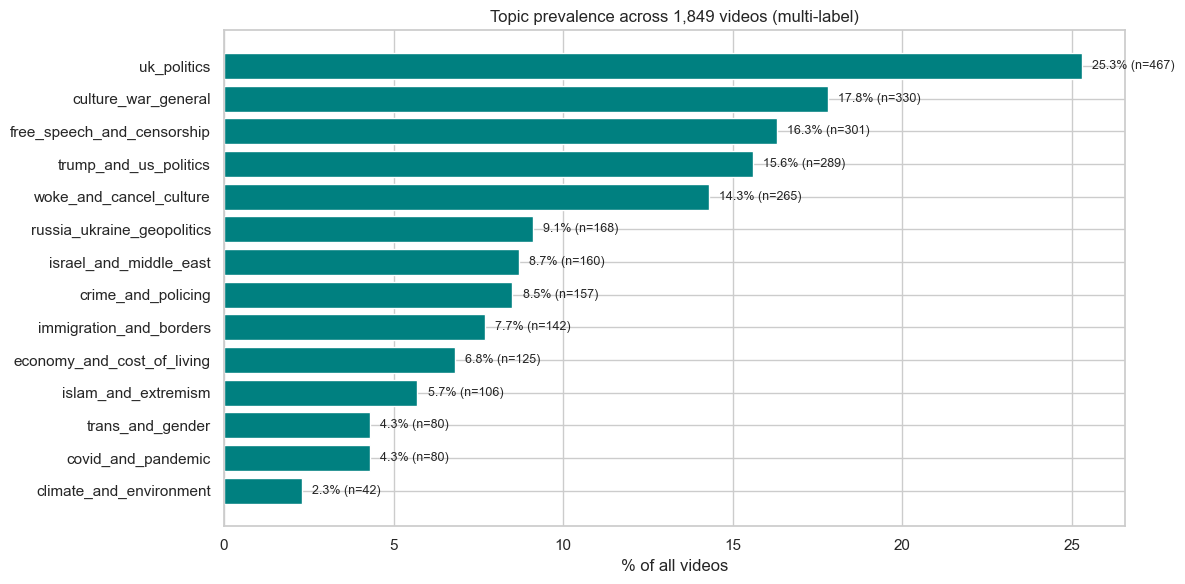

In [9]:
# Bar chart — topic prevalence
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(topic_df["topic"], topic_df["pct"], color="teal")
ax.invert_yaxis()
ax.set_xlabel("% of all videos")
ax.set_title(f"Topic prevalence across {len(df):,} videos (multi-label)")
for i, (pct, cnt) in enumerate(zip(topic_df["pct"], topic_df["count"])):
    ax.text(pct + 0.3, i, f"{pct}% (n={cnt})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

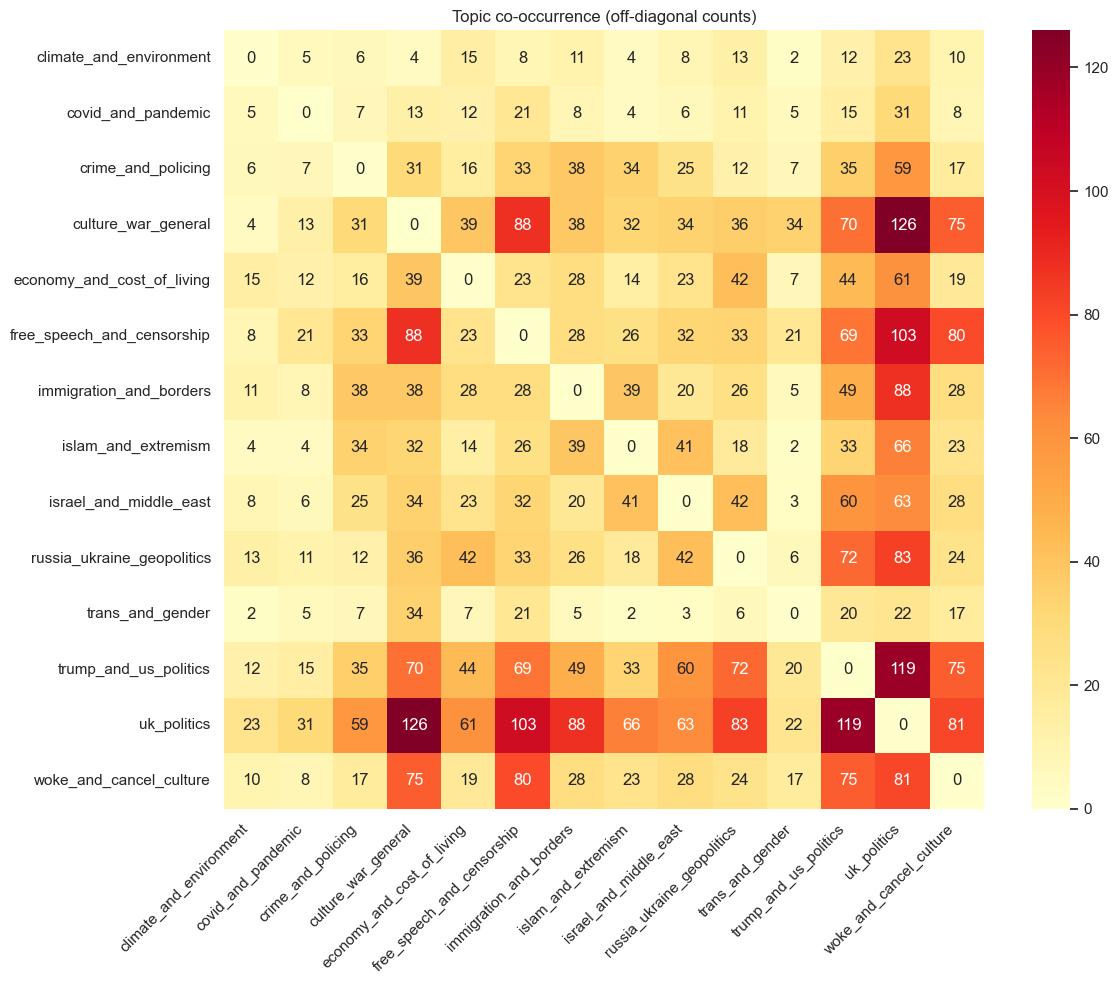

In [10]:
# Topic co-occurrence heatmap
topic_names = sorted(TOPIC_KEYWORDS.keys())
topic_cooc = pd.DataFrame(0, index=topic_names, columns=topic_names)

for topics in df["topics"]:
    for a in topics:
        for b in topics:
            topic_cooc.loc[a, b] += 1

# Zero the diagonal for readability
diag_vals = topic_cooc.to_numpy(copy=True)
np.fill_diagonal(diag_vals, 0)
topic_cooc = pd.DataFrame(diag_vals, index=topic_names, columns=topic_names)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(topic_cooc, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Topic co-occurrence (off-diagonal counts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

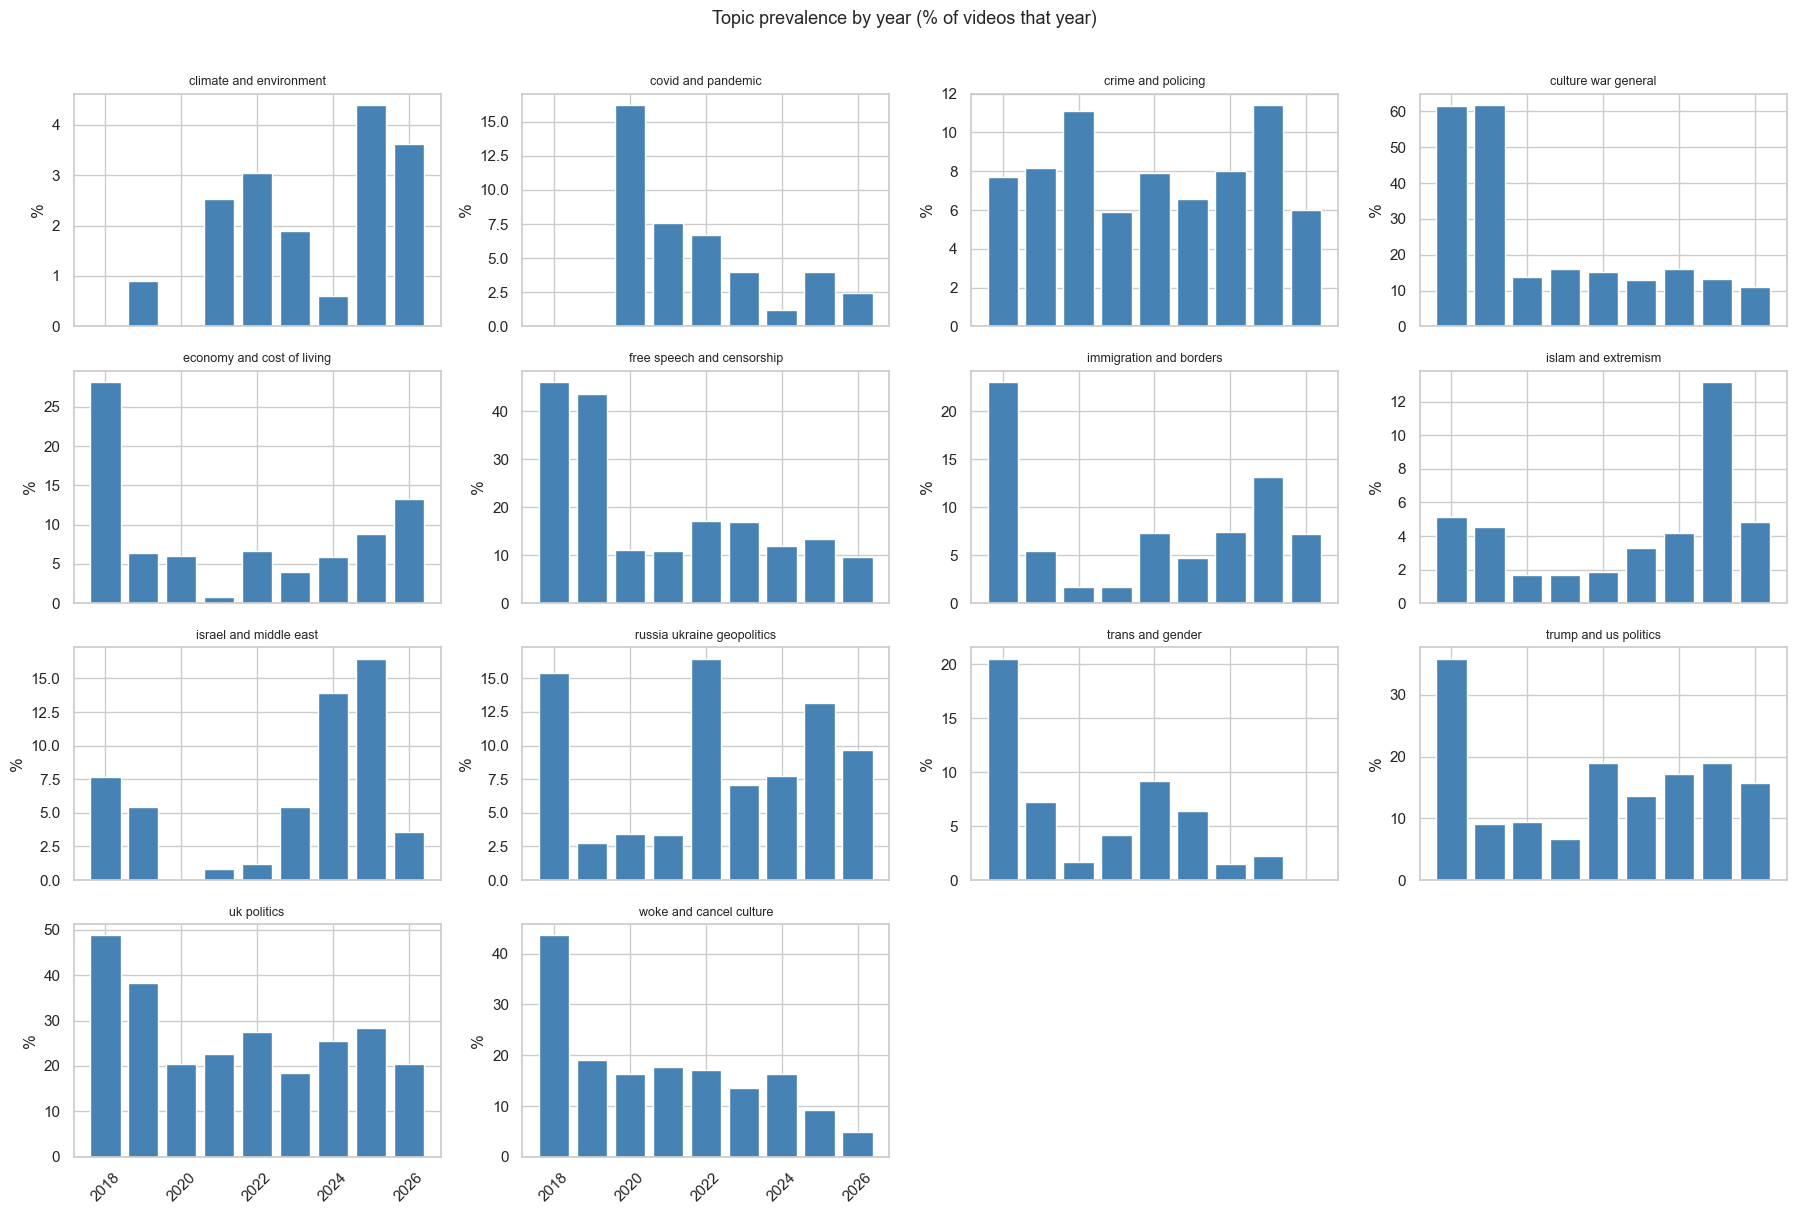

In [11]:
# Topic prevalence over time (small multiples)
years = sorted(df["year"].unique())
year_video_counts = df["year"].value_counts().sort_index()

ncols = 4
nrows = int(np.ceil(len(topic_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True)

for idx, topic in enumerate(sorted(topic_names)):
    ax = axes.flat[idx]
    rates = []
    for y in years:
        year_mask = df["year"] == y
        n_year = year_mask.sum()
        n_topic = df.loc[year_mask, "topics"].apply(lambda t: topic in t).sum()
        rates.append(n_topic / n_year * 100 if n_year else 0)
    ax.bar(years, rates, color="steelblue")
    ax.set_title(topic.replace("_", " "), fontsize=9)
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=45)

# Hide unused axes
for idx in range(len(topic_names), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.suptitle("Topic prevalence by year (% of videos that year)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Audit: sample of uncategorised videos
uncategorised = df[df["n_topics"] == 0][["published_date", "title", "tags"]]
print(f"Uncategorised videos: {len(uncategorised):,}")
print()
uncategorised.sample(min(20, len(uncategorised)), random_state=42)

Uncategorised videos: 601



,published_date,title,tags
473,2022-07-22,The Critical Drinker's Top 5 Movies,triggernometry|triggerpod|konstantin kisin|fra...
1421,2025-05-25,"""We have a disaster on our hands here."" - Matt...",triggernometry|triggerpod|konstantin kisin|fra...
1779,2026-01-11,How They Ruined California,triggernometry|triggerpod|konstantin kisin|fra...
354,2021-09-17,"Sex, Religion, Evolution: Bret Weinstein & Hea...",NaN
666,2023-04-22,Brits Shoot Guns In America 🇺🇸🇺🇸 #shorts,triggernometry|triggerpod|konstantin kisin|fra...
955,2023-12-10,This social experiment will BLOW your mind 👀 #...,triggernometry|triggerpod|konstantin kisin|fra...
154,2020-01-17,"Pinchas Landau: ""Saudi Arabia is a Medieval Co...",triggernometry|triggerpod|konstantin kisin|fra...
1565,2025-08-14,"What happened in St Pancras, Tommy?",triggernometry|triggerpod|konstantin kisin|fra...
355,2021-09-19,Jordan Peterson on the Fear of Death,triggernometry|triggerpod|konstantin kisin|fra...
1114,2024-03-28,Are We Doing Democracy Wrong? - Konstantin Kisin,triggernometry|triggerpod|konstantin kisin|fra...


### 1b — Guest identity signal

Guest identity carries political signal that pure text analysis misses. This dictionary
maps culturally/politically prominent guests to their known talking points. The guest
signal **only fires when the episode's detected topics overlap** with the guest's
known talking points (per-episode context approach).

This avoids mislabelling: e.g. Sam Harris appearing on an episode about AI gets no
guest signal, but Sam Harris on an episode about Islam does.

> Guest leanings are based on documented public positions, party affiliations,
> published works, and on-record statements — not editorial judgement about arguments.

In [13]:
# ── Guest leanings dictionary ─────────────────────────────────────────
# Each entry maps a guest name to their known political leaning and the
# specific talking-point topics where that leaning applies.
# Guest signal ONLY fires when episode topics overlap with talking_points.

GUEST_LEANINGS = {
    # ── User-validated forced signals ────────────────────────────────────
    "Andrew Doyle": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "free_speech_and_censorship", "culture_war_general"],
        "force_signal": True,
        "notes": "GB News host, authored anti-woke books",
    },
    "Ben Shapiro": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Republican commentator, Daily Wire founder",
    },
    "Laurence Fox": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "immigration_and_borders", "culture_war_general", "trans_and_gender"],
        "force_signal": True,
        "notes": "Ran far-right ethnonationalist party Reclaim UK",
    },
    # ── UK right-wing commentators ───────────────────────────────────────
    "Douglas Murray": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "islam_and_extremism", "immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-wing cultural commentator",
    },
    "Matt Goodwin": {
        "leaning": "right",
        "talking_points": ["immigration_and_borders", "uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Reform UK (unsuccessful candidate), ethnonationalist commentary",
    },
    "Matthew Goodwin": {
        "leaning": "right",
        "talking_points": ["immigration_and_borders", "uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Reform UK (unsuccessful candidate), ethnonationalist commentary",
    },
    "Peter Hitchens": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Conservative commentator",
    },
    "Mike Graham": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "TalkTV/TalkRadio right-wing host",
    },
    "Nigel Farage": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "Reform UK leader, right-wing populist",
    },
    "Tommy Robinson": {
        "leaning": "right",
        "talking_points": ["islam_and_extremism", "immigration_and_borders", "uk_politics"],
        "force_signal": True,
        "notes": "Far-right activist",
    },
    "Patrick Christys": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "GB News presenter",
    },
    "Toby Young": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "woke_and_cancel_culture", "uk_politics"],
        "force_signal": True,
        "notes": "Right-wing free speech advocate",
    },
    "David Starkey": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Right-wing traditionalist historian",
    },
    "Melanie Phillips": {
        "leaning": "right",
        "talking_points": ["uk_politics", "islam_and_extremism", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-wing conservative columnist",
    },
    "Iain Dale": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Former Conservative politician, center-right broadcaster",
    },
    "Geoff Norcott": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Conservative comedian",
    },
    "Simon Evans": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Right-leaning conservative comedian",
    },
    "Dominic Frisby": {
        "leaning": "contested",
        "talking_points": ["economy_and_cost_of_living", "uk_politics"],
        "force_signal": False,
        "notes": "Libertarian comedian; 'We're All Far Right Now' is parody/irony mocking classification",
    },
    "Matt Ridley": {
        "leaning": "right",
        "talking_points": ["climate_and_environment", "covid_and_pandemic", "economy_and_cost_of_living"],
        "force_signal": True,
        "notes": "Conservative peer, climate skeptic, free-market libertarian",
    },
    "Liam Halligan": {
        "leaning": "right",
        "talking_points": ["economy_and_cost_of_living", "uk_politics"],
        "force_signal": True,
        "notes": "Pro-Brexit center-right economist",
    },
    "Katharine Birbalsingh": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Small-c conservative, anti-woke education advocate",
    },
    "Robert Jenrick": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Reform UK, former Conservative minister",
    },
    "Mahyar Tousi": {
        "leaning": "right",
        "talking_points": ["uk_politics", "islam_and_extremism", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Right-wing YouTuber",
    },
    "Laila Cunningham": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Reform UK politician",
    },
    # ── US right-wing commentators ───────────────────────────────────────
    "Jordan Peterson": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "woke_and_cancel_culture", "trans_and_gender", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Pro-MAGA, right-wing cultural commentator",
    },
    "Tim Pool": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Right-wing commentator",
    },
    "Ann Coulter": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-wing political pundit",
    },
    "Greg Gutfeld": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Fox News host",
    },
    "Adam Carolla": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Conservative/libertarian commentator",
    },
    "Jeremy Boreing": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Daily Wire co-founder and CEO",
    },
    "Andrew Klavan": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Daily Wire host",
    },
    "Steve Hilton": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "uk_politics", "economy_and_cost_of_living"],
        "force_signal": True,
        "notes": "Fox News host, former UK Conservative advisor",
    },
    "Dr Sebastian Gorka": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "islam_and_extremism"],
        "force_signal": True,
        "notes": "Former Trump administration official",
    },
    "Sebastian Gorka": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "islam_and_extremism"],
        "force_signal": True,
        "notes": "Former Trump administration official",
    },
    "Nick Freitas": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "israel_and_middle_east"],
        "force_signal": True,
        "notes": "Republican politician, conservative/libertarian",
    },
    "Michael Malice": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Anarcho-capitalist, right-libertarian",
    },
    "Roseanne Barr": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Trump supporter, right-wing conservative",
    },
    "Dana White": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Trump supporter, UFC CEO",
    },
    "Richard Miniter": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Conservative author and journalist",
    },
    # ── Anti-woke/culture war commentators ───────────────────────────────
    "James Lindsay": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general", "trans_and_gender"],
        "force_signal": True,
        "notes": "Anti-woke activist, Christian nationalist aligned",
    },
    "Critical Drinker": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Anti-woke film critic",
    },
    "The Critical Drinker": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Anti-woke film critic",
    },
    "Zuby": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general", "trans_and_gender"],
        "force_signal": True,
        "notes": "Right-wing commentator; 'Identifying as a Woman and White Privilege' = sarcastic, mocking trans",
    },
    "Lionel Shriver": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "free_speech_and_censorship", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-woke conservative-leaning author",
    },
    "Count Dankula": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Right-wing comedian, free speech activist",
    },
    "Posie Parker": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-trans activist",
    },
    "Graham Linehan": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-trans activist",
    },
    # ── Islam critics / Middle East commentators ─────────────────────────
    "Raymond Ibrahim": {
        "leaning": "right",
        "talking_points": ["islam_and_extremism", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-Islam author and commentator",
    },
    "John Spencer": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Pro-Israel military analyst",
    },
    # ── Academics / historians ───────────────────────────────────────────
    "Niall Ferguson": {
        "leaning": "right",
        "talking_points": ["uk_politics", "trump_and_us_politics", "economy_and_cost_of_living", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Center-right conservative historian",
    },
    "Sir Niall Ferguson": {
        "leaning": "right",
        "talking_points": ["uk_politics", "trump_and_us_politics", "economy_and_cost_of_living", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Center-right conservative historian",
    },
    "Eric Kaufmann": {
        "leaning": "right",
        "talking_points": ["immigration_and_borders", "culture_war_general", "uk_politics"],
        "force_signal": True,
        "notes": "Conservative academic on demography and culture",
    },
    "Dominic Sandbrook": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Center-right traditionalist historian",
    },
    # ── Socially conservative / heterodox commentators ───────────────────
    "Freya India": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Anti-woke conservative writer",
    },
    "Louise Perry": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "trans_and_gender"],
        "force_signal": True,
        "notes": "Socially conservative reactionary feminist",
    },
    "Helen Andrews": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Conservative writer",
    },
    "Rory Sutherland": {
        "leaning": "right",
        "talking_points": ["economy_and_cost_of_living", "culture_war_general"],
        "force_signal": True,
        "notes": "Classical liberal with conservative leanings",
    },
    # ── IDW / contested figures ──────────────────────────────────────────
    "Eric Weinstein": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "IDW figure, conspiracy theories",
    },
    "Bret Weinstein": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "woke_and_cancel_culture", "covid_and_pandemic"],
        "force_signal": True,
        "notes": "Anti-woke, COVID conspiracy theories",
    },
    "Jimmy Carr": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Pro-right positions",
    },
    "Sam Harris": {
        "leaning": "contested",
        "talking_points": ["islam_and_extremism"],
        "notes": "Critical of Trump but islamophobic; platformed for specific talking points",
        "style": "heterodox",
    },
    "Glenn Greenwald": {
        "leaning": "contested",
        "talking_points": ["trump_and_us_politics", "free_speech_and_censorship"],
        "notes": "Libertarian socialist, anti-establishment, aligns with right-wing media",
        "style": "heterodox",
    },
    "Paul Embery": {
        "leaning": "contested",
        "talking_points": ["uk_politics", "immigration_and_borders"],
        "notes": "Blue Labour - economically left, socially conservative",
    },
    "Melissa Chen": {
        "leaning": "contested",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "notes": "Classical liberal, critiques progressive left",
    },
    # ── Additional right-wing guests ─────────────────────────────────────
    "Dinesh D'Souza": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-wing filmmaker, Trump pardoned",
    },
    "Dan Wootton": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "GB News presenter",
    },
    "Batya Ungar-Sargon": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Right-wing populist author",
    },
    "Maya Forstater": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Gender critical activist",
    },
    "Debbie Hayton": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Trans-critical trans commentator",
    },
    "Alex Phillips": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders"],
        "force_signal": True,
        "notes": "GB News presenter, former Brexit Party MEP",
    },
    "Mike Nayna": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-woke documentary maker",
    },
    "Candace Owens": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Right-wing commentator",
    },
    "Tucker Carlson": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Right-wing media figure",
    },
    "Peter Boghossian": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-woke academic",
    },
    "Helen Dale": {
        "leaning": "right",
        "talking_points": ["uk_politics", "immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-leaning commentator",
    },
    "Dave Rubin": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-wing commentator, former liberal",
    },
    "Charlie Kirk": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Turning Point USA founder",
    },
    "Tony Hinchcliffe": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-leaning comedian",
    },
    "Winston Marshall": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-woke commentator",
    },
    "Andrew Tate": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Far-right influencer",
    },
    "Maryam Namazie": {
        "leaning": "right",
        "talking_points": ["islam_and_extremism", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Anti-Islamist activist",
    },
    "Robin Aitken": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "BBC bias critic",
    },
    "Fraser Nelson": {
        "leaning": "right",
        "talking_points": ["uk_politics", "economy_and_cost_of_living"],
        "force_signal": True,
        "notes": "Spectator editor, conservative",
    },
    "Tom Slater": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "culture_war_general"],
        "force_signal": True,
        "notes": "Spiked editor",
    },
    "Brendan O'Neill": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "culture_war_general", "woke_and_cancel_culture"],
        "force_signal": True,
        "notes": "Spiked editor, contrarian",
    },
    "Claire Fox": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "uk_politics"],
        "force_signal": True,
        "notes": "Brexit Party MEP, free speech advocate",
    },
    "Kehinde Andrews": {
        "leaning": "left",
        "talking_points": ["culture_war_general"],
        "notes": "Left-wing academic - debates count as centrist",
    },
    "Aaron Bastani": {
        "leaning": "left",
        "talking_points": ["uk_politics", "economy_and_cost_of_living"],
        "notes": "Novara Media, left-wing",
    },
    # ── COVID conspiracy / vaccine skeptic guests ────────────────────────
    "Robert Malone": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "culture_war_general"],
        "force_signal": True,
        "notes": "COVID vaccine skeptic, mRNA misinformation",
    },
    "Pierre Kory": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "Ivermectin promoter",
    },
    "Peter McCullough": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "COVID vaccine misinformation",
    },
    "Aseem Malhotra": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "UK vaccine skeptic cardiologist",
    },
    "Jay Bhattacharya": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "culture_war_general"],
        "force_signal": True,
        "notes": "Great Barrington Declaration, anti-lockdown",
    },
    "Sunetra Gupta": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "Great Barrington Declaration",
    },
    "Carl Heneghan": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "COVID skeptic, lockdown critic",
    },
    "Alex Berenson": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "culture_war_general"],
        "force_signal": True,
        "notes": "COVID/vaccine misinformation journalist",
    },
    "Naomi Wolf": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "culture_war_general"],
        "force_signal": True,
        "notes": "Former feminist turned COVID conspiracy theorist",
    },
    "Robert F Kennedy Jr": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Anti-vaccine activist",
    },
    "RFK Jr": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Anti-vaccine activist",
    },
    "Joe Rogan": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "culture_war_general", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Platforming COVID misinformation, right-wing drift",
    },
    "Russell Brand": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "culture_war_general"],
        "force_signal": True,
        "notes": "Former left turned COVID/conspiracy content creator",
    },
    # ── Health hucksters / non-medical professionals ─────────────────────
    "Dr Shawn Baker": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Carnivore diet promoter, anti-establishment medicine",
    },
    "Shawn Baker": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Carnivore diet promoter",
    },
    "Paul Saladino": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Carnivore diet, anti-mainstream medicine",
    },
    "Mikhaila Peterson": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "covid_and_pandemic"],
        "force_signal": True,
        "notes": "Carnivore diet, COVID skeptic, Jordan Peterson's daughter",
    },
    "Dr John Campbell": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "YouTube COVID skeptic, vaccine misinformation",
    },
    "John Campbell": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "YouTube COVID skeptic",
    },
    "Isabel Oakeshott": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic", "uk_politics"],
        "force_signal": True,
        "notes": "Right-wing journalist, lockdown skeptic",
    },
    "Julia Hartley-Brewer": {
        "leaning": "right",
        "talking_points": ["uk_politics", "covid_and_pandemic", "culture_war_general"],
        "force_signal": True,
        "notes": "TalkRadio host, lockdown skeptic",
    },
    "Prof Karol Sikora": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "COVID lockdown skeptic",
    },
    "Karol Sikora": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "COVID lockdown skeptic",
    },
    # ── Gender critical / trans debate guests ────────────────────────────
    "Helen Joyce": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Gender critical author",
    },
    "Sharron Davies": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-trans in sports campaigner",
    },
    "Buck Angel": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Trans man critical of trans activism",
    },
    "Exulansic": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Detransition content creator",
    },
    "Caolan Robertson": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "trans_and_gender"],
        "force_signal": True,
        "notes": "Right-wing content creator",
    },
    "Kathleen Stock": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Gender critical philosopher",
    },
    "J.K. Rowling": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Gender critical, anti-trans activism",
    },
    "JK Rowling": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Gender critical",
    },
    # ── Additional right-wing guests (user identified) ───────────────────
    "Nick Fuentes": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "White nationalist, groyper movement",
    },
    "Brandon Tatum": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "crime_and_policing", "culture_war_general"],
        "force_signal": True,
        "notes": "Officer Tatum, conservative commentator",
    },
    "Officer Tatum": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "crime_and_policing", "culture_war_general"],
        "force_signal": True,
        "notes": "Brandon Tatum, conservative commentator",
    },
    "Allister Heath": {
        "leaning": "right",
        "talking_points": ["uk_politics", "economy_and_cost_of_living"],
        "force_signal": True,
        "notes": "Telegraph editor, right-wing",
    },
    "Naftali Bennett": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east"],
        "force_signal": True,
        "notes": "Former Israeli PM, right-wing",
    },
    "Benjamin Netanyahu": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east"],
        "force_signal": True,
        "notes": "Israeli PM, right-wing Likud",
    },
    "Erik Prince": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Blackwater founder, Trump ally",
    },
    "Tony Abbott": {
        "leaning": "right",
        "talking_points": ["uk_politics", "climate_and_environment"],
        "force_signal": True,
        "notes": "Former Australian PM, conservative",
    },
    "Wilfred Reilly": {
        "leaning": "right",
        "talking_points": ["crime_and_policing", "culture_war_general"],
        "force_signal": True,
        "notes": "Conservative academic, hate crime hoax/denying racism",
    },
    "BJ Dichter": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Freedom Convoy organizer, Canadian right-wing",
    },
    "Konstantin Kisin": {
        "leaning": "host",
        "talking_points": [],
        "force_signal": False,
        "notes": "TRIGGERnometry host; contested — let lexicon/sentiment decide per video",
    },
    "Liz Truss": {
        "leaning": "right",
        "talking_points": ["uk_politics", "economy_and_cost_of_living", "culture_war_general"],
        "force_signal": True,
        "notes": "Former UK PM, right-wing, became more libertarian right",
    },
    "Andrew Gold": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Heretics podcast, right-leaning",
    },
    "Kelsi Sheren": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Conservative commentator, MAID critic",
    },
    "Rob Hersov": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "South African businessman, conservative",
    },
    "Peter Bleksley": {
        "leaning": "right",
        "talking_points": ["crime_and_policing", "islam_and_extremism"],
        "force_signal": True,
        "notes": "Ex-police detective, anti-Islamist",
    },
    "Yossi Cohen": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east"],
        "force_signal": True,
        "notes": "Former Mossad director",
    },
    "Daniel Di Martino": {
        "leaning": "right",
        "talking_points": ["economy_and_cost_of_living", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Venezuelan anti-socialist commentator",
    },
    "Kathryn Porter": {
        "leaning": "right",
        "talking_points": ["climate_and_environment"],
        "force_signal": True,
        "notes": "Anti-renewables energy analyst",
    },
    "Stephen J. Shaw": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Population collapse documentary maker",
    },
    "Dr Paul Morland": {
        "leaning": "right",
        "talking_points": ["immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "Demographer, anti-immigration",
    },
    "Paul Morland": {
        "leaning": "right",
        "talking_points": ["immigration_and_borders", "culture_war_general"],
        "force_signal": True,
        "notes": "Demographer, anti-immigration",
    },
    "Jim Rickards": {
        "leaning": "right",
        "talking_points": ["economy_and_cost_of_living", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Economic doomist, gold advocate",
    },
    # ── From unclassified-guests review (user + context) ───────────────────
    "Colin Wright": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Gender essentialist anti-trans talking head",
    },
    "Richard Dawkins": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Transphobe, atheist commentator",
    },
    "Christopher Rufo": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "MAGA-affiliated, CRT dog-whistle campaigner",
    },
    "Stephen Fry": {
        "leaning": "contested",
        "talking_points": ["culture_war_general"],
        "force_signal": False,
        "notes": "Centrist",
    },
    "Roger Hallam": {
        "leaning": "left",
        "talking_points": ["climate_and_environment"],
        "force_signal": False,
        "notes": "Extinction Rebellion/Just Stop Oil co-founder, radical left",
        "style": "revolutionary",
    },
    "Combat Veteran Nick Freitas": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east"],
        "force_signal": True,
        "notes": "Pro-Israel genocide denial framing",
    },
    "Nick Freitas": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Combat veteran, pro-Israel",
    },
    "Sharron Davies MBE": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Gender-critical, women's sports",
    },
    "Dr Sebastian Gorka": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Trump advisor",
    },
    "Seb Gorka": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Trump advisor",
    },
    "John Spencer": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east"],
        "force_signal": True,
        "notes": "War expert, pro-Israel Gaza framing",
    },
    "Michael Shellenberger": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "Twitter Files, anti-woke",
        "style": "conspiratorial",
    },
    "Christopher Rufo": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "trump_and_us_politics"],
        "force_signal": True,
        "notes": "MAGA-affiliated, CRT dog-whistle campaigner",
    },
    "Pinchas Landau": {
        "leaning": "right",
        "talking_points": ["islam_and_extremism", "israel_and_middle_east"],
        "force_signal": True,
        "notes": "Saudi medieval framing is Islamophobic",
    },
    "Megyn Kelly": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Conservative commentator",
    },
    "Matt Walsh": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-trans commentator",
    },
    "Andy Ngo": {
        "leaning": "right",
        "talking_points": ["crime_and_policing", "culture_war_general"],
        "force_signal": True,
        "notes": "Antifa critic",
    },
    "Victor Davis Hanson": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Conservative historian",
    },
    "Dennis Prager": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "PragerU founder",
    },
    "Kevin Roberts": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Heritage Foundation, Project 2025",
    },
    "Libs of TikTok": {
        "leaning": "right",
        "talking_points": ["trans_and_gender", "culture_war_general"],
        "force_signal": True,
        "notes": "Anti-trans, grooming narrative",
    },
    "Natasha Hausdorff": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east"],
        "force_signal": True,
        "notes": "Pro-Israel, genocide denial",
    },
    "Dr Jay Bhattacharya": {
        "leaning": "right",
        "talking_points": ["covid_and_pandemic"],
        "force_signal": True,
        "notes": "Great Barrington, lockdown skeptic",
        "style": "conspiratorial",
    },
    "Mike Benz": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Deep state conspiracy",
        "style": "conspiratorial",
    },
    "Pearl Davis": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Interviewed Nick Fuentes",
    },
    "Dr David Starkey": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Woke culture critic",
    },
    "Neil Oliver": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "GB News, nationalist",
    },
    "Nigel Biggar": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Colonialism defender",
    },
    "Bruce Gilley": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Colonialism defender",
    },
    "Rob Schneider": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Trump supporter",
    },
    "Bill Ackman": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Trump supporter",
    },
    "Ariel Pink": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Trump rally attendee",
    },
    "Lauren Southern": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Far-right commentator",
    },
    "Peter Thiel": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Tech billionaire, right-wing",
    },
    "Richard Hanania": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Woke origins, right-coded",
    },
    "Abigail Shrier": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Anti-trans, Irreversible Damage",
    },
    "Debra Soh": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Gender essentialist",
    },
    "Blaire White": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Anti-trans trans woman",
    },
    "Buck Angel": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Stop medicalising kids",
    },
    "Jamie Reed": {
        "leaning": "right",
        "talking_points": ["trans_and_gender"],
        "force_signal": True,
        "notes": "Trans clinic whistleblower, gender-critical",
    },
    "Heather Mac Donald": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Universities betrayed",
    },
    "Dan Crenshaw": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Republican congressman",
    },
    "Dave Smith": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Libertarian, Nick Fuentes/Tucker",
        "style": "resentment",
    },
    "Patrick Bet-David": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Anti-establishment right",
        "style": "resentment",
    },
    "Kevin Sorbo": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Hollywood blacklist, conservative",
    },
    "Viva Frei": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Canada Freedom Convoy",
    },
    "Yoram Hazony": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Liberalism cannot defeat wokeness",
        "style": "resentment",
    },
    "Gad Saad": {
        "leaning": "right",
        "talking_points": ["culture_war_general"],
        "force_signal": True,
        "notes": "Bad ideas destroying the West",
        "style": "resentment",
    },
    "Dr Sebastian Gorka": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics"],
        "force_signal": True,
        "notes": "Trump advisor",
    },
    "Sargon of Akkad": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Far-right podcaster (Carl Benjamin)",
    },
    "Benjamin Boyce": {
        "leaning": "contested",
        "talking_points": ["culture_war_general", "woke_and_cancel_culture"],
        "force_signal": False,
        "notes": "Anti-woke/social justice critic (Evergreen), aligns with right on critique",
        "style": "heterodox",
    },

    # ── From unknowns-review.md manual classification ────────────────────
    "Tulsi Gabbard": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Former Democrat, joined Trump admin as DNI, MAGA",
    },
    "Allison Pearson": {
        "leaning": "right",
        "talking_points": ["uk_politics", "free_speech_and_censorship", "culture_war_general", "crime_and_policing"],
        "force_signal": True,
        "notes": "Daily Telegraph columnist, conservative",
    },
    "Declan Ganley": {
        "leaning": "right",
        "talking_points": ["free_speech_and_censorship", "russia_ukraine_geopolitics", "culture_war_general"],
        "force_signal": True,
        "notes": "Irish businessman, founded EU-skeptic party Libertas",
    },
    "Lois McLatchie Miller": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "trans_and_gender"],
        "force_signal": True,
        "notes": "ADF International, conservative Christian legal advocacy",
    },
    "Dr Pippa Malmgren": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "economy_and_cost_of_living", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Economist, served in George W. Bush White House",
    },
    "Pippa Malmgren": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "economy_and_cost_of_living", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Economist, served in George W. Bush White House",
    },
    "Presidential Advisor Dr Pippa Malmgren": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "economy_and_cost_of_living", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Economist, served in George W. Bush White House",
    },
    "Jason Calacanis": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "immigration_and_borders"],
        "force_signal": True,
        "notes": "Tech investor, right-libertarian, pro-Trump",
    },
    "Piers Morgan": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general", "israel_and_middle_east"],
        "force_signal": True,
        "notes": "Center-right broadcaster, anti-woke",
    },
    "James Whale": {
        "leaning": "right",
        "talking_points": ["uk_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Right-wing UK broadcaster",
    },
    "Ed Husain": {
        "leaning": "right",
        "talking_points": ["islam_and_extremism", "israel_and_middle_east", "uk_politics"],
        "force_signal": True,
        "notes": "Former Islamist turned center-right critic of Islamism",
    },
    "Elica Le Bon": {
        "leaning": "right",
        "talking_points": ["israel_and_middle_east", "trump_and_us_politics", "russia_ukraine_geopolitics"],
        "force_signal": True,
        "notes": "Iranian-American anti-regime activist, hawkish on Iran",
    },
    "Leo Kearse": {
        "leaning": "right",
        "talking_points": ["culture_war_general", "uk_politics"],
        "force_signal": True,
        "notes": "Right-leaning political comedian",
    },
    "Alan Dershowitz": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "israel_and_middle_east"],
        "force_signal": True,
        "notes": "Historically liberal Democrat, became pro-Trump legal commentator",
    },
    "Andrew Bustamante": {
        "leaning": "right",
        "talking_points": ["trump_and_us_politics", "russia_ukraine_geopolitics", "israel_and_middle_east"],
        "force_signal": True,
        "notes": "Ex-CIA, frequently appears on right-wing media",
    },
    "Bassem Youssef": {
        "leaning": "left",
        "talking_points": ["israel_and_middle_east", "culture_war_general"],
        "force_signal": True,
        "notes": "Egyptian satirist, pro-Palestinian, progressive",
    },
    "Scott Galloway": {
        "leaning": "contested",
        "talking_points": ["economy_and_cost_of_living", "culture_war_general"],
        "force_signal": False,
        "notes": "NYU Stern professor, pragmatic liberal/moderate Democrat. Pro-wealth-redistribution and anti-big-tech but departs from progressive left on masculinity crisis, pro-capitalism, and critiques of wokeness. Similar profile to Bill Maher.",
        "style": "heterodox",
    },
    "Duncan Trussell": {
        "leaning": "left",
        "talking_points": ["free_speech_and_censorship", "culture_war_general"],
        "force_signal": True,
        "notes": "Left-libertarian comedian and podcaster",
    },
    "Charlamagne tha God": {
        "leaning": "left",
        "talking_points": ["trump_and_us_politics", "culture_war_general", "crime_and_policing"],
        "force_signal": True,
        "notes": "Center-left radio host, Democrat-aligned",
    },
    "Destiny": {
        "leaning": "left",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Center-left political streamer (Steven Bonnell)",
    },
    "Steven Bonnell": {
        "leaning": "left",
        "talking_points": ["trump_and_us_politics", "culture_war_general"],
        "force_signal": True,
        "notes": "Center-left political streamer (Destiny)",
    },
    "Rory Stewart": {
        "leaning": "contested",
        "talking_points": ["uk_politics", "russia_ukraine_geopolitics"],
        "force_signal": False,
        "notes": "Former Conservative MP, anti-Brexit, anti-populist right, centrist",
        "style": "heterodox",
    },
    "Matthew Syed": {
        "leaning": "contested",
        "talking_points": ["uk_politics", "immigration_and_borders", "israel_and_middle_east"],
        "force_signal": False,
        "notes": "Centrist journalist and author",
        "style": "heterodox",
    },

    # ── Politically unaffiliated / neutral ───────────────────────────────

    "Helen Pluckrose": {
        "leaning": "right",
        "talking_points": ["woke_and_cancel_culture", "culture_war_general", "free_speech_and_censorship"],
        "force_signal": True,
        "notes": "Co-author Cynical Theories with James Lindsay, Grievance Studies hoax, anti-woke",
    },
    "Alex O'Connor": {
        "leaning": "contested",
        "talking_points": [],
        "force_signal": False,
        "notes": "Politically unaffiliated, neutral. YouTuber/philosopher (CosmicSkeptic)",
    },
    "Bill Maher": {
        "leaning": "contested",
        "talking_points": ["culture_war_general", "woke_and_cancel_culture", "covid_and_pandemic"],
        "force_signal": False,
        "notes": "Traditional liberal, critic of woke/COVID policies, platforms conservatives",
        "style": "heterodox",
    },
}

# Optional style metadata: conspiratorial | heterodox | revolutionary | resentment
# Used for filtering/analysis; does not affect scoring (wing does).
def get_guest_style(guest_name):
    """Return style from GUEST_LEANINGS. Empty string if not set."""
    if guest_name is None or (isinstance(guest_name, str) and not guest_name.strip()):
        return ""
    try:
        lookup = guest_name
        if guest_name not in GUEST_LEANINGS:
            for k in sorted(GUEST_LEANINGS.keys(), key=len, reverse=True):
                if isinstance(guest_name, str) and k in guest_name:
                    lookup = k
                    break
            else:
                return ""
        entry = GUEST_LEANINGS.get(lookup)
        return entry.get("style", "") if entry else ""
    except (TypeError, AttributeError):
        return ""

# ── Guest name extraction (adapted from notebook 04) ─────────────────
HOSTS = {"konstantin kisin", "francis foster", "konstantine kisin"}
FALSE_POSITIVES = {
    "raw", "debate", "live", "news", "update", "trailer",
    "our thoughts", "your questions", "special episode",
    "jre podcast", "joe rogan podcast",  # podcast name, not guest
    "nazis",  # from "Stop Calling Everyone You Disagree With Nazis"
    "viral speech",  # format label, not guest
    "identity politics",  # topic, not guest
}
SENTENCE_WORDS = {
    "gets", "destroys", "reveals", "exposes", "reacts", "explains",
    "admits", "responds", "attacks", "defends", "confronts", "drops",
    "wins", "loses", "breaks", "makes", "takes", "keeps", "stops",
    "tries", "does", "says", "goes", "comes", "has", "had", "was",
    "is", "are", "been", "being", "fact-checked",
}
TITLE_PREFIX = r"(?:(?:Sir|Dr|Dr\.|Prof|Professor|Baroness|Lord|Dame|Major|Captain|Rev|Bishop)\s+)?"
NAME_WORD = r"[A-Z][a-zA-Z'\.'\-]+"
NAME_PAT = TITLE_PREFIX + NAME_WORD + r"(?:\s+(?:of\s+)?" + NAME_WORD + r"){0,4}"
NAME_PAT_SHORT = TITLE_PREFIX + NAME_WORD + r"(?:\s+(?:of\s+)?" + NAME_WORD + r"){0,2}"


def _is_plausible_name(name):
    lower = name.lower()
    if lower in HOSTS or lower in FALSE_POSITIVES:
        return False
    if len(name) <= 2:
        return False
    if name.isupper() and len(name.split()) == 1:
        return False
    words = name.split()
    for w in words[1:]:
        if w.lower() in SENTENCE_WORDS:
            return False
    return True


def extract_guest_name(title):
    t = title.strip().strip('"').strip("'")

    # Pattern 1: "Topic - Guest Name"
    m = re.search(r'\s[-\u2013\u2014]\s+(' + NAME_PAT + r')\s*$', t)
    if m and _is_plausible_name(m.group(1).strip()):
        return m.group(1).strip()

    # Pattern 2: "Guest Name: 'Quote'" or "Guest Name: Statement"
    m = re.match(r'^(' + NAME_PAT + r')\s*[:]\s', t)
    if m:
        name = m.group(1).strip()
        skip = {"the", "a", "an", "this", "that", "how", "why", "what", "when",
                "where", "is", "are", "our", "their", "his", "her", "its", "we",
                "net", "labour", "brexit", "venezuela", "congratulations", "finally"}
        if len(name.split()) >= 1 and name.split()[0].lower() not in skip and _is_plausible_name(name):
            return name

    # Pattern 3: "Guest Name on Topic"
    m = re.match(r'^(' + NAME_PAT_SHORT + r')\s+on\s+', t)
    if m and _is_plausible_name(m.group(1).strip()):
        return m.group(1).strip()

    # Pattern 4: "Topic ... with Guest Name"
    m = re.search(r'\b[Ww]ith\s+(' + NAME_PAT + r')\s*$', t)
    if m and _is_plausible_name(m.group(1).strip()):
        return m.group(1).strip()

    return None


PERSON_ANALYSIS_PATH = Path(DATA_PATH).resolve().parents[2] / "scripts/utils/yt-channel-data/notebooks/person-analysis.md"


def load_right_guest_hints(md_path: Path) -> set[str]:
    """Load right-leaning guest names from person-analysis notes."""
    if not md_path.exists():
        return set()

    text = md_path.read_text(encoding="utf-8", errors="ignore")
    lines = [line.strip() for line in text.splitlines()]

    header = "Name,Self-Identification,External Analysis & Audience Alignment,Considered Right-Wing?"
    if header not in lines:
        return set()

    start_idx = lines.index(header)
    csv_lines = [line for line in lines[start_idx:] if line and line.count(",") >= 3]

    right_names = set()
    for row in csv.DictReader(csv_lines):
        name = (row.get("Name") or "").strip()
        label = (row.get("Considered Right-Wing?") or "").strip().lower()
        if not name:
            continue
        is_right = (
            "yes" in label
            or "far-right" in label
            or "center-right" in label
            or label == "right"
        )
        if is_right and not label.startswith("no"):
            right_names.add(name)

    return right_names


RIGHT_GUEST_HINTS = load_right_guest_hints(PERSON_ANALYSIS_PATH)
print(f"Loaded right-guest hints from person-analysis.md: {len(RIGHT_GUEST_HINTS)}")


def compute_guest_signal(row):
    """Compute guest-based political signal.

    Returns (guest_name, guest_signal, matched_talking_points, notes).
    Default rule: signal fires when episode topics overlap with guest talking points.
    Overrides:
      - force_signal=True for user-validated guests (always classify)
      - person-analysis right-guest hints for lightweight fallback signal
    """
    guest = extract_guest_name(str(row["title"]))
    if guest is None:
        return None, 0.0, [], ""

    # Substring match: e.g. "Konstantin Kisin Holberg Debate Speech" -> "Konstantin Kisin"
    lookup_guest = guest
    if guest not in GUEST_LEANINGS:
        for k in sorted(GUEST_LEANINGS.keys(), key=len, reverse=True):
            if k in guest:
                lookup_guest = k
                break
    entry = GUEST_LEANINGS.get(lookup_guest)
    if entry is None:
        if lookup_guest in RIGHT_GUEST_HINTS or guest in RIGHT_GUEST_HINTS:
            return guest, 0.75, ["person_analysis_right_guest"], "Right-leaning guest from person-analysis.md"
        return guest, 0.0, [], ""

    # Check topic overlap + configured force override
    episode_topics = set(row["topics"]) if isinstance(row["topics"], list) else set()
    matched_points = list(episode_topics & set(entry["talking_points"]))
    force_signal = bool(entry.get("force_signal", False))

    if not matched_points and not force_signal:
        # Optional weak fallback when person-analysis also flags this guest as right-leaning
        if entry.get("leaning") == "right" and guest in RIGHT_GUEST_HINTS:
            notes = f"{entry['notes']} | right-guest hint from person-analysis.md"
            return guest, 0.75, ["person_analysis_right_guest"], notes
        return guest, 0.0, [], entry["notes"]

    if force_signal and not matched_points:
        matched_points = ["guest_override"]

    # Signal fires: +1 for right, -1 for left, 0 for contested
    leaning = entry["leaning"]
    if leaning == "right":
        signal = 1.0
    elif leaning == "left":
        signal = -1.0
    elif leaning == "host":
        signal = 0.0  # host: let lexicon/sentiment decide, no identity signal
    else:  # contested
        signal = 0.5  # weaker signal for contested guests

    return guest, signal, matched_points, entry["notes"]


# Apply guest signal to all videos
guest_results = df.apply(compute_guest_signal, axis=1, result_type="expand")
guest_results.columns = ["guest_name_detected", "guest_signal", "guest_talking_points_matched", "guest_notes"]
df = pd.concat([df, guest_results], axis=1)
df["guest_style"] = df["guest_name_detected"].apply(get_guest_style)

# Summary
n_with_guest = (df["guest_name_detected"].notna()).sum()
n_with_signal = (df["guest_signal"] != 0).sum()
n_in_dict = df["guest_name_detected"].apply(lambda g: g in GUEST_LEANINGS if g else False).sum()

forced_hits = df["guest_talking_points_matched"].apply(
    lambda x: isinstance(x, list) and "guest_override" in x
).sum()
person_hint_hits = df["guest_talking_points_matched"].apply(
    lambda x: isinstance(x, list) and "person_analysis_right_guest" in x
).sum()

print(f"Guest names extracted:               {n_with_guest:,}")
print(f"Guests in GUEST_LEANINGS:            {n_in_dict:,}")
print(f"Right-guest hints loaded (notes):    {len(RIGHT_GUEST_HINTS):,}")
print(f"Guest signal fires (all mechanisms): {n_with_signal:,}")
print(f"  of which forced overrides:         {forced_hits:,}")
print(f"  of which person-analysis hints:    {person_hint_hits:,}")
print(f"\nGuest signal breakdown:")
print(df[df["guest_signal"] != 0].groupby("guest_name_detected")["guest_signal"].agg(["count", "mean"]).to_string())


Loaded right-guest hints from person-analysis.md: 35
Guest names extracted:               860
Guests in GUEST_LEANINGS:            435
Right-guest hints loaded (notes):    35
Guest signal fires (all mechanisms): 444
  of which forced overrides:         153
  of which person-analysis hints:    7

Guest signal breakdown:
                                           count  mean
guest_name_detected                                   
Aaron Bastani                                  1 -1.00
Abigail Shrier                                 1  1.00
Adam Carolla                                   4  1.00
Adam Carolla Unfiltered                        1  1.00
Alex Phillips                                  1  1.00
Allison Pearson                                1  1.00
Allister Heath                                 2  1.00
Andrew Bustamante                              2  1.00
Andrew Doyle                                  19  1.00
Andrew Doyle Live                              2  1.00
Andrew Gold        

---

## 2 — Political framing lexicon (context-aware)

Mere presence of a term does **not** indicate framing direction. "White privilege" can appear in a title like *"White Privilege is a Racist Concept"* — that's right-leaning framing *using* left-coded language as a critique target.

The lexicon is split into two tiers:

- **Tier 1 — Unambiguous**: Terms that are inherently directional regardless of context (e.g., "woke", "cancel culture", "nanny state" are always right-coded pejoratives)
- **Tier 2 — Contested**: Left-coded terms (e.g., "white privilege", "systemic racism", "far right") that need surrounding context to score. We look for **critique markers** (scare quotes, "myth", "lie", "debunks", "so-called", "truth about", negation) vs **endorsement markers** ("real", "address", "acknowledge") within a text window around the term.

A contested term used critically → right-leaning framing (+1)  
A contested term used approvingly → left-leaning framing (−1)  
A contested term with no clear signal → **ambiguous** (scored 0, flagged for review)

In [14]:
# ── Tier 1: Unambiguous right-framing terms ──────────────────────────
# Presence alone scores +1. These are inherently right-coded vocabulary.
TIER1_RIGHT = [
    # Woke / cancel culture critique
    "woke", "wokeness", "wokeism", "woke mob",
    "cancel culture", "virtue signal", "virtue signalling",
    "identity politics", "thought police", "snowflake", "nanny state",
    "anti-woke",
    "culture war",
    "political correctness", "politically correct",
    # Immigration framing
    "illegal immigrant", "illegal alien", "illegal migrant",
    "open border", "invasion",
    "grooming gang", "grooming gangs",
    "mass immigration", "mass migration",
    "migrant crisis", "migration crisis",
    # Gender / sex framing
    "gender ideology", "trans lobby",
    "men in women", "protect women",
    "they/them",
    "childless cat ladies", "cat ladies",
    "trans women are men", "trans women aren't women",
    # National / traditional framing
    "western civilisation", "western values", "war on the west",
    "judeo christian", "family values", "silent majority",
    "great replacement",
    "multiculturalism failed", "failed multiculturalism",
    # Anti-establishment / anti-censorship
    "deplatformed", "silenced",
    "mainstream media", "msm",
    "deep state",
    "bbc bias", "anti-trump bias",
    "liberal bias", "media bias",
    "tried to cancel", "cancel me",
    # Climate scepticism
    "net zero must go", "economic suicide",
    "climate alarmism", "climate hysteria",
    # Covid scepticism / vaccine denial / conspiracy framing
    "lockdown sceptic", "lab leak", "natural immunity",
    "covid tyranny", "plandemic",
    "mass hysteria",
    "vaccine injury", "vaccine injuries", "vaccine damage",
    "vaccine mandate", "forced vaccination", "medical tyranny",
    "big pharma", "pharma lies", "pharma corruption",
    "fauci lied", "fauci lies",
    "wuhan lab", "china virus", "china must pay",
    "experimental vaccine", "experimental injection",
    "mrna danger", "spike protein",
    "died suddenly", "excess deaths",
    "ivermectin", "hydroxychloroquine",
    "medical freedom", "bodily autonomy",
    "trust the science", "follow the science",  # often used sarcastically by skeptics
    # Anti-trans medicine framing
    "puberty blockers", "puberty blocker",
    "child mutilation", "mutilating children",
    "gender affirming", "gender-affirming",  # often used critically
    "trans surgery", "sex change",
    "sterilizing children", "sterilisation",
    "cass review", "tavistock",
    "rapid onset", "rogd",  # rapid onset gender dysphoria (contested diagnosis)
    "social contagion",
    "trans clinic", "gender clinic",
    "trans drag", "drag queen",
    "trans debate", "gender debate",
    "trans women aren't", "trans women are not",
    "male athletes", "women's sports",
    "vaccine hesitancy",
    "lockdown was", "lockdowns were",
    "vaccine passport", "vaccine passports",
    "covid authoritarianism",
    "medicalising kids", "medicalizing kids",
    # Anti-left / anti-Labour framing (UK)
    "labour failed", "labour destroyed",
    "the left is", "leftist",
    "socialist", "socialism failed",
    "marxism", "marxist",
    "communism", "communist",
    # Loaded verbs common in right-leaning titles
    "destroys", "exposes", "dismantles", "obliterates",
    "slams", "debunks",
    "ruined california", "they ruined",
    # Anti-government / conspiracy revelation framing
    "dirty secret", "truth bomb",
    "they don't want you", "they won't tell",
    "they're lying", "being lied to",
    "nobody voted for", "you didn't vote for",
    "the elites", "elite agenda",
    # Reform UK / right-wing party framing
    "reform uk", "joined reform",
    # Crisis / fear framing
    "civil war", "on the brink",
    "civilisation collapse", "society collapse",
    "blood on their hands",
    # Anti-immigration framing
    "island of strangers",
    "migrant hotel", "migrant crisis",
    "open borders",
    "convicted murderer" ,  # immigration context
    # Elite/establishment critique
    "elites betrayed", "elite betrayal",
    "political class", "ruling class",
    # Anti-tax framing
    "taxed the rich",
    # Gender critical
    "gender critical",
    "biological reality",
    # Other right-coded terms
    "red pill", "based",
    "two-tier", "two tier",
    "free thinker", "common sense",
    # Specific topics
    "southport", "grooming gangs",
    "gb news",
    # Free speech framing
    "free speech crisis", "censorship",
    "deplatform", "silenced",
    # Islam criticism
    "religion of peace", "radical islam", "islamism",
    # Brexit / nationalism
    "what does it mean to be english", "what does it mean to be british",
    "britain first", "british identity",
    "country without a border",
    # Benefits / welfare critique
    "on benefits", "benefit fraud",
    # Gender critical
    "detransition", "detransitioner",
    # Anti-Labour specific
    "starmer is", "keir starmer is",
    # Immigration general
    "illegal immigration",
    # ── Islamophobia / anti-Islam framing ────────────────────────────────
    "islam plus jihadism", "islamist violence", "islamist terror",
    "sharia law", "creeping sharia", "islamic extremism",
    "the problem with islam", "radical islam", "islamic threat",
    "muslim no-go", "grooming gang", "rape gang",
    "two-tier policing", "two tier policing",
    # ── Terms moved from TIER1_LEFT → TIER1_RIGHT ──────────────────────
    # FINDING: Manual review of every occurrence on this channel confirmed
    # that the following terms are NEVER used with positive valence. They
    # appear exclusively in critical, mocking, or adversarial framing:
    #   - "antifa" / "anti-fascist" / "anti-racist": always anti-antifa
    #     conspiratorialism or exposé framing (e.g. Andy Ngo coverage).
    #   - "social justice" / "grievance studies" / "sjw": always positioned
    #     as ideological threat, never endorsed.
    #   - "defund" / "abolish police": always critical of defunding.
    #   - "safe space": always used mockingly.
    # Because these terms carry uniformly negative (i.e. right-wing
    # critical) valence in this dataset, scoring them as left-framing
    # produces systematic misclassification. They are right-framing
    # signals on this channel.
    "social justice", "grievance studies", "sjw",
    "antifa", "anti-fascist", "anti-racist",
    "defund", "abolish police",
    "safe space",
    # ── Left philosophy dangerous framing ────────────────────────────────
    "dangerous philosophy", "left's dangerous", "far-left is anti",
    "leftism is", "liberalism has failed", "progressive ideology",
    "cultural marxism", "postmodern neo-marxism", "neo-marxist",
    # ── Christian nationalism / pro-Christian framing ────────────────────
    "decline of christianity", "post-christian", "christian values",
    "what christianity has that islam doesn't", "judeo-christian",
    "western civilisation", "western civilization", "christendom",
    # ── Pro-Israel / anti-Palestine framing ──────────────────────────────
    "it's not genocide", "not a genocide", "hamas want",
    "israel's right to defend", "antisemitism on the left",
    "pro-hamas", "terror sympathiser", "terror sympathizer",
    "from the river to the sea", "intifada",
    # ── Anti-diversity framing ───────────────────────────────────────────
    "diversity is not a strength", "diversity isn't a strength",
    "myth of multiculturalism", "multiculturalism has failed",
    "forced diversity", "dei is", "dei has",
    # ── Anti-renewables / climate skeptic framing ────────────────────────
    "renewables are not cheap", "renewables aren't cheap",
    "net zero madness", "net zero is", "green agenda",
    "climate alarmism", "climate doom",
    # ── Pro-policing / law-and-order framing ─────────────────────────────
    "they made crime legal", "crime is legal",
    "police won't investigate", "police don't investigate",
    "bias in policing", "soft on crime",
    "broken system", "the system is broken",
    # ── Trump support framing ────────────────────────────────────────────
    "trump was right", "trump is right",
    "trump derangement", "tds",
    # ── Antisemitic conspiracy framing (even when pro-Israel) ────────────
    "rothschild", "rothschilds",
    # ── Population collapse / natalist framing ───────────────────────────
    "population collapse", "birth rate crisis",
    "demographic decline", "we're not having enough",
    # ── Anti-socialist / Venezuela framing ───────────────────────────────
    "socialism is", "socialism doesn't work",
    "venezuela is what happens", "socialist experiment",
    # ── Hate crime denial / denying racism framing ───────────────────────
    "lying about hate crimes", "they're lying about hate crimes",
    "hate crime hoax", "hate crime hoaxes",
    # ── Decline of the West framing ──────────────────────────────────────
    "decline of the west", "west's decline", "stop the west",
    "how to stop the west", "west's last chance",
    # ── DEI & slavery conflation (right-coded framing) ───────────────────
    "dei & slavery", "dei and slavery",
    "the west, dei", "dei & slavery",
    # ── Title-based inference (user guidance) ────────────────────────────
    "headed for civil war", "we're headed for",
    "civil war", "civil war",
    "male athletes are stealing", "stealing opportunities from women",
    "trans women aren't allowed", "trans women have an unfair",
    "complaining about biden", "biden presidency won't",
    "kamala harris", "kamala harris is scared",
    "saudi arabia is medieval", "saudi arabia is a medieval",
    "critical race theory", "ugly truth about critical race",
    "it's not genocide", "not genocide", "what hamas want",
    "sex is not a spectrum", "sex is not a spectrum",
    # "Identifying as a woman and white privilege" — sarcastic/mocking trans (right-coded)
    "identifying as a woman and white privilege",
]

# ── Tier 1: Unambiguous left-framing terms ───────────────────────────
# Presence alone scores -1. These are inherently left-coded vocabulary.
TIER1_LEFT = [
    # NOTE: On this channel, left-coded terms almost always appear in CRITICAL
    # framing. Terms that are consistently used mockingly or as right-wing
    # attack vectors have been moved to TIER1_RIGHT. Only terms that could
    # genuinely signal left-endorsing content remain here.
    "racial justice", "climate justice",
    "decolonise", "decolonize",
    # Progressive economic framing
    "eat the rich", "tax the rich", "universal basic income",
    "late capitalism",
    # Identity framing (genuinely endorsing only)
    "allyship", "privilege check",
    "lived experience",
]

# ── Tier 2: Contested terms (need context) ───────────────────────────
TIER2_CONTESTED = [
    "white privilege", "white supremacy",
    "systemic racism", "structural inequality", "institutional racism",
    "intersectionality",
    "marginalised", "oppressed",
    "climate crisis", "climate emergency", "climate justice",
    "far right", "hard right",
    "undocumented", "asylum seeker", "refugee crisis",
    "hostile environment",
    "gender affirming", "trans rights", "reproductive rights",
    "fact check",
    "misinformation", "disinformation",
    "wealth inequality", "living wage", "austerity",
    "billionaire class", "late capitalism", "public ownership",
]

# ── Rhetorical title patterns ────────────────────────────────────────
# Regex patterns that match common right-wing YouTube title framing.
# Each fires as +1 right-framing signal when matched in the TITLE only.
import re as _re

TITLE_PATTERNS_RIGHT = [
    # "Why X is FAILING / WRONG / DOOMED" — declinist framing
    _re.compile(r"(?i)\bwhy\b.{1,40}\b(fail|wrong|doomed|broken|dying|dead|over|finished)\b"),
    # "X is DESTROYING / RUINING Y" — catastrophist framing
    _re.compile(r"(?i)\b(destroy|ruin|kill|wreck|erode|undermine|dismantle)ing\b"),
    # "The TRUTH about X" — revelation/expose framing
    _re.compile(r"(?i)\bthe\s+truth\s+about\b"),
    # "X ADMITS / REVEALS / CONFESSES" — gotcha framing
    _re.compile(r"(?i)\b(admits?|confesses?|reveals?|finally)\b.*\b(truth|wrong|mistake|lied|lying)\b"),
    # ALL CAPS emphasis (3+ words) — clickbait escalation
    _re.compile(r"\b[A-Z]{4,}\b.*\b[A-Z]{4,}\b"),
    # Sarcastic quote framing ("Fight For Your Right To Assault Women")
    _re.compile(r"(?i)\bright\s+to\b.{1,30}\b(assault|attack|harm|silence|censor)\b"),
    # Anti-left framing: "The Left is/has/must..."
    _re.compile(r"(?i)\bthe\s+left\b.{1,30}\b(must|wrong|fail|abandon|despis|destroy|ruin|racist|broken)\b"),
    # "How X Ruined/Destroyed/Broke Y"
    _re.compile(r"(?i)\bhow\b.{1,30}\b(ruin|destroy|broke|wreck|kill)(?:ed|s)?\b"),
    # Anti-Labour/government critique: "Labour should/must..."
    _re.compile(r"(?i)\b(labour|starmer|government)\s+(should|must|failed|is\s+finished|lied|lying)\b"),
    # "They RUINED X" framing
    _re.compile(r"(?i)\bthey\s+(ruined|destroyed|broke|wrecked|failed)\b"),
    # "X Must Go" framing (e.g. "Net Zero Must Go")
    _re.compile(r"(?i)\b\w+\s+must\s+go\b"),
    # "I Exposed X Bias" — media critique framing
    _re.compile(r"(?i)\b(exposed?|reveal|uncover)\w*\s+.{0,20}\bbias\b"),
    # "X is a joke" framing
    _re.compile(r"(?i)\bbecoming\s+a\s+joke\b"),
    # "Nobody voted for X" — democratic outrage framing
    _re.compile(r"(?i)\bnobody\s+voted\s+for\b"),
    # "You've been lied to" — distrust framing
    _re.compile(r"(?i)\byou'?ve\s+been\s+lied\s+to\b"),
    # "X is Finished" framing
    _re.compile(r"(?i)\b(starmer|labour|the\s+left|biden|democrats?)\s+is\s+finished\b"),
    # "Is X a religion of peace" framing
    _re.compile(r"(?i)\bis\s+islam\s+a\s+religion\s+of\s+peace\b"),
    # "What does it mean to be X" - national identity framing
    _re.compile(r"(?i)\bwhat\s+does\s+it\s+mean\s+to\s+be\s+(english|british)\b"),
    # "Britain/UK is moving right" - political movement
    _re.compile(r"(?i)\b(britain|uk|england)\s+is\s+moving\s+right\b"),
    # "What do we do about X" - problem framing on immigration
    _re.compile(r"(?i)\bwhat\s+do\s+we\s+do\s+about\s+(illegal\s+)?immigration\b"),
    # "Britain's X Crisis" - crisis framing
    _re.compile(r"(?i)\b(britain|uk|england)'?s?\s+\w+\s+crisis\b"),
    # COVID conspiracy framing
    _re.compile(r"(?i)\b(china|wuhan)\s+(must\s+pay|created|released|lied)\b"),
    _re.compile(r"(?i)\bvaccine\s+(injury|injuries|damage|dangers?|deaths?)\b"),
    _re.compile(r"(?i)\b(fauci|who|cdc)\s+(lied|lying|corrupt|cover.?up)\b"),
    _re.compile(r"(?i)\bdied\s+suddenly\b"),
    _re.compile(r"(?i)\bexcess\s+deaths?\b"),
    # Anti-trans medicine framing
    _re.compile(r"(?i)\b(mutilat|steriliz)\w*\s+(children|kids|minors)\b"),
    _re.compile(r"(?i)\bpuberty\s+blockers?\s+(danger|harm|damage)\b"),
    _re.compile(r"(?i)\bgender\s+(clinic|surgery)\s+(scandal|horror|danger)\b"),
    # ── Islamophobia / anti-Islam framing ────────────────────────────────
    _re.compile(r"(?i)\bislam(ist)?\s+(plus|and)\s+(jihadism|terrorism|violence)\b"),
    _re.compile(r"(?i)\bthe\s+reality\s+of\s+(uk\s+)?muslims?\b"),
    _re.compile(r"(?i)\bwhy\s+(they|we)\s+can'?t\s+be\s+honest\s+about\s+islam\b"),
    _re.compile(r"(?i)\b(grooming|rape)\s+gang\b"),
    _re.compile(r"(?i)\btwo.?tier\s+policing\b"),
    # ── Pro-Israel / Netanyahu defense framing ───────────────────────────
    _re.compile(r"(?i)\b(it'?s\s+not|not\s+a)\s+genocide\b"),
    _re.compile(r"(?i)\bnetanyahu\s+(calls\s+out|responds?|challenge)\b"),
    _re.compile(r"(?i)\bisrael'?s?\s+(right\s+to\s+defend|response)\b"),
    _re.compile(r"(?i)\bwho\s+is\s+responsible\s+for.{0,20}gaza\b"),
    _re.compile(r"(?i)\bfrom\s+the\s+river\s+to\s+the\s+sea\s+means\b"),
    _re.compile(r"(?i)\bex.?israeli\s+(pm|prime\s+minister)\b"),
    # ── Diversity critique framing ───────────────────────────────────────
    _re.compile(r"(?i)\bdiversity\s+is(n'?t|\s+not)\s+a?\s*strength\b"),
    _re.compile(r"(?i)\b(myth|failure)\s+of\s+multiculturalism\b"),
    _re.compile(r"(?i)\bis\s+diversity\s+(more\s+important|a\s+strength)\b"),
    _re.compile(r"(?i)\bdei\s+(is|must|has|agenda)\b"),
    # ── Christian nationalism / western civilization framing ─────────────
    _re.compile(r"(?i)\b(decline|death)\s+of\s+christianity\b"),
    _re.compile(r"(?i)\bwhat\s+christianity\s+has\s+that\s+islam\b"),
    _re.compile(r"(?i)\b(save|saving|defend)\s+western\s+(civilisation|civilization)\b"),
    # ── Anti-renewables / energy framing ─────────────────────────────────
    _re.compile(r"(?i)\brenewables?\s+(are|aren'?t|not)\s+(cheap|working)\b"),
    _re.compile(r"(?i)\bnet\s+zero\s+(must|is|madness|agenda)\b"),
    # ── Pro-policing / law-and-order framing ─────────────────────────────
    _re.compile(r"(?i)\bthey\s+made\s+crime\s+legal\b"),
    _re.compile(r"(?i)\bpolice\s+(don'?t|won'?t)\s+investigate\b"),
    _re.compile(r"(?i)\b(bias|two.?tier)\s+in\s+(uk\s+)?policing\b"),
    # ── Population collapse / natalist framing ───────────────────────────
    _re.compile(r"(?i)\b(population|demographic|birth\s+rate)\s+(collapse|crisis|decline)\b"),
    _re.compile(r"(?i)\bwe'?re\s+not\s+having\s+enough\s+(kids|children|babies)\b"),
    # ── Anti-socialist / Venezuela framing ───────────────────────────────
    _re.compile(r"(?i)\bsocialism\s+is\s+(a\s+dream|dangerous|failing)\b"),
    _re.compile(r"(?i)\b(harsh|horrific)\s+reality\s+of.{0,20}venezuela\b"),
    # ── Trump support framing ────────────────────────────────────────────
    _re.compile(r"(?i)\btrump\s+(was|is)\s+right\b"),
    _re.compile(r"(?i)\btrump'?s?\s+(vision|plan|deal)\b"),
    # ── Antisemitic trope framing (even when pro-Israel) ─────────────────
    _re.compile(r"(?i)\brothschild(s)?\s+(famous|made|banking|trade)\b"),
    _re.compile(r"(?i)\bi\s+look\s+like\s+a\s+jew\b"),
    # ── Left philosophy dangerous framing ────────────────────────────────
    _re.compile(r"(?i)\b(the\s+)?left'?s?\s+(dangerous|toxic)\s+(philosophy|ideology)\b"),
    _re.compile(r"(?i)\bfar.?left\s+is\s+(anti.?western|dangerous)\b"),
    _re.compile(r"(?i)\bwhy\s+(socialism|leftism|liberalism)\s+(is\s+)?(popular|failing|dangerous)\b"),
    # ── Hate crime denial framing ────────────────────────────────────────
    _re.compile(r"(?i)\b(they'?re|they\s+are)\s+lying\s+about\s+hate\s+crimes\b"),
    _re.compile(r"(?i)\bhate\s+crime\s+(hoax|hoaxes|fraud)\b"),
    # ── Decline of the West framing ───────────────────────────────────────
    _re.compile(r"(?i)\b(how\s+to\s+)?stop\s+the\s+west'?s?\s+(decline|declining)\b"),
    _re.compile(r"(?i)\bwest'?s?\s+(decline|last\s+chance)\b"),
    _re.compile(r"(?i)\bdecline\s+of\s+the\s+west\b"),
    # ── DEI & slavery conflation (Kisin defending right views) ───────────
    _re.compile(r"(?i)\b(dei|the\s+west)\s*[,&]\s*slavery\b"),
    _re.compile(r"(?i)\bdebate.*dei.*slavery\b"),
    # ── Title-based inference (user guidance) ────────────────────────────
    _re.compile(r"(?i)\b(are\s+we\s+)?headed\s+for\s+civil\s+war\b"),
    _re.compile(r"(?i)\bmale\s+athletes?\s+(are\s+)?stealing\s+(opportunities?|from)\b"),
    _re.compile(r"(?i)\bstealing\s+opportunities?\s+from\s+women\b"),
    _re.compile(r"(?i)\bsaudi\s+arabia\s+is\s+(a\s+)?medieval\b"),
    _re.compile(r"(?i)\b(ugly\s+truth\s+about\s+)?critical\s+race\s+theory\b"),
    _re.compile(r"(?i)\b(it'?s\s+not\s+genocide|not\s+genocide).*(hamas|what\s+hamas)\b"),
    _re.compile(r"(?i)\bkamala\s+harris\s+(is\s+)?(scared|afraid)\b"),
    _re.compile(r"(?i)\bbiden\s+(presidency|won'?t)\s+(won'?t\s+heal|heal)\b"),
    _re.compile(r"(?i)\bsam\s+harris\s+vs\s+eric\s+weinstein.*israel.?palestine\b"),
]

# ── Context markers ──────────────────────────────────────────────────
CRITIQUE_MARKERS = [
    "myth", "lie", "lies", "nonsense", "hoax", "fiction", "fake",
    "absurd", "ridiculous", "debunk", "debunks", "debunked", "debunking",
    "so-called", "so called", "supposed", "scare", "hysteria",
    "truth about", "real reason", "really",
    "doesn't exist", "does not exist", "don't exist", "isn't real", "not real",
    "aren't", "isn't", "not", "no such",
    "problem with", "wrong with", "against",
    "overused", "weaponised", "weaponized", "smear", "label",
    "garbage", "rubbish", "bull",
    "racist concept", "divisive",
    "quotation mark",  # meta-signal
]

ENDORSEMENT_MARKERS = [
    "acknowledge", "address", "fight for", "fight against",
    "support", "important", "real problem", "exists",
    "need to", "must", "urgent", "protect",
]

# Context window (characters each side of the matched term)
CTX_WINDOW = 80

# Tags weight — tags are editorial metadata (SEO choices), weighted lower than title/desc
TAGS_WEIGHT = 0.5

print(f"Tier 1 (unambiguous right): {len(TIER1_RIGHT)} terms")
print(f"Tier 1 (unambiguous left):  {len(TIER1_LEFT)} terms")
print(f"Tier 2 (contested):         {len(TIER2_CONTESTED)} terms")
print(f"Title patterns (right):     {len(TITLE_PATTERNS_RIGHT)} regex patterns")
print(f"Critique markers:           {len(CRITIQUE_MARKERS)}")
print(f"Endorsement markers:        {len(ENDORSEMENT_MARKERS)}")
print(f"Tags weight:                {TAGS_WEIGHT}")


Tier 1 (unambiguous right): 320 terms
Tier 1 (unambiguous left):  11 terms
Tier 2 (contested):         29 terms
Title patterns (right):     79 regex patterns
Critique markers:           44
Endorsement markers:        12
Tags weight:                0.5


In [15]:
def extract_context(text, term, window=CTX_WINDOW):
    """Return the text window surrounding a term match."""
    idx = text.find(term)
    if idx == -1:
        return ""
    start = max(0, idx - window)
    end = min(len(text), idx + len(term) + window)
    return text[start:end]


def has_scare_quotes(text, term):
    """Check if the term appears inside quotation marks (scare quotes)."""
    for q in ['"', '\u201c', '\u201d', "'", "\u2018", "\u2019"]:
        idx = text.find(term)
        if idx == -1:
            continue
        before = text[max(0, idx - 3):idx]
        after = text[idx + len(term):idx + len(term) + 3]
        if q in before or q in after:
            return True
    return False


def classify_contested_term(text, term):
    """Determine whether a contested term is used critically or approvingly.
    Returns: +1 (critique -> right-framing), -1 (endorsement -> left-framing), 0 (ambiguous)
    """
    ctx = extract_context(text, term).lower()
    if not ctx:
        return 0, "not_found"

    if has_scare_quotes(text, term):
        return +1, "scare_quotes"

    for marker in CRITIQUE_MARKERS:
        if marker in ctx:
            return +1, f"critique:{marker}"

    for marker in ENDORSEMENT_MARKERS:
        if marker in ctx:
            return -1, f"endorsement:{marker}"

    return 0, "ambiguous"


def score_text_source(text_lower, text_raw, source_label, weight=1.0):
    """Score a single text source against the lexicon.

    Returns (right_hits, left_hits, ambiguous_hits, evidence) where hits are
    lists of (term, weight) tuples.
    """
    right_hits = []
    left_hits = []
    ambiguous_hits = []
    evidence = []

    # Tier 1 RIGHT
    for term in TIER1_RIGHT:
        if term in text_lower:
            right_hits.append((term, weight))
            evidence.append(f"[T1R +{weight}] {term} ({source_label})")

    # Tier 1 LEFT
    for term in TIER1_LEFT:
        if term in text_lower:
            left_hits.append((term, weight))
            evidence.append(f"[T1L -{weight}] {term} ({source_label})")

    # Tier 2: contested terms — need context (only for title/desc, not tags)
    if source_label != "tags":
        for term in TIER2_CONTESTED:
            if term not in text_lower:
                continue
            score, reason = classify_contested_term(text_raw.lower(), term)
            if score == 0 and has_scare_quotes(text_raw, term.title()):
                score, reason = +1, "scare_quotes"
            if score == 0 and has_scare_quotes(text_raw, term.upper()):
                score, reason = +1, "scare_quotes"
            if score > 0:
                right_hits.append((term, weight))
                evidence.append(f"[T2 +{weight}] {term} ({source_label}, {reason})")
            elif score < 0:
                left_hits.append((term, weight))
                evidence.append(f"[T2 -{weight}] {term} ({source_label}, {reason})")
            else:
                ambiguous_hits.append((term, weight))
                evidence.append(f"[T2  0] {term} ({source_label}, {reason})")

    return right_hits, left_hits, ambiguous_hits, evidence


def score_title_patterns(title_raw):
    """Score title against rhetorical patterns. Returns (right_hits, evidence)."""
    right_hits = []
    evidence = []
    for pattern in TITLE_PATTERNS_RIGHT:
        m = pattern.search(title_raw)
        if m:
            matched_text = m.group(0)[:50]
            right_hits.append((f"pattern:{matched_text}", 1.0))
            evidence.append(f"[PAT +1] \"{matched_text}\" (title)")
    return right_hits, evidence


def compute_framing(row):
    """Context-aware political framing score, including tags and title patterns."""
    title_lower = str(row["title"]).lower()
    title_raw = str(row["title"])
    desc_lower = str(row["desc_clean"]).lower()
    desc_raw = str(row["desc_clean"])
    tags_str = " ".join(row["tags_list"]) if isinstance(row["tags_list"], list) else ""

    all_right = []
    all_left = []
    all_ambiguous = []
    all_evidence = []

    # Score title (weight 1.0)
    r, l, a, e = score_text_source(title_lower, title_raw, "title", weight=1.0)
    all_right.extend(r); all_left.extend(l); all_ambiguous.extend(a); all_evidence.extend(e)

    # Score description (weight 1.0)
    r, l, a, e = score_text_source(desc_lower, desc_raw, "desc", weight=1.0)
    all_right.extend(r); all_left.extend(l); all_ambiguous.extend(a); all_evidence.extend(e)

    # Score tags (weight 0.5)
    r, l, a, e = score_text_source(tags_str, tags_str, "tags", weight=TAGS_WEIGHT)
    tags_right = r
    tags_left = l
    all_right.extend(r); all_left.extend(l); all_ambiguous.extend(a); all_evidence.extend(e)

    # Score title patterns (weight 1.0)
    pat_right, pat_evidence = score_title_patterns(title_raw)
    all_right.extend(pat_right)
    all_evidence.extend(pat_evidence)

    # Compute scores
    right_score = sum(w for _, w in all_right)
    left_score = sum(w for _, w in all_left)
    framing_score = right_score - left_score

    # Tags-only score for audit
    tags_framing_score = sum(w for _, w in tags_right) - sum(w for _, w in tags_left)

    return pd.Series({
        "framing_right_count": right_score,
        "framing_left_count": left_score,
        "framing_ambiguous_count": len(all_ambiguous),
        "framing_score": framing_score,
        "framing_right_terms": [t for t, _ in all_right],
        "framing_left_terms": [t for t, _ in all_left],
        "framing_ambiguous_terms": [t for t, _ in all_ambiguous],
        "framing_evidence": all_evidence,
        "tags_framing_score": tags_framing_score,
        "tags_framing_terms": [t for t, _ in tags_right + tags_left],
    })


framing = df.apply(compute_framing, axis=1)
df = pd.concat([df, framing], axis=1)

print(f"Videos with >=1 right-framing signal:  {(df['framing_right_count'] > 0).sum():,}")
print(f"Videos with >=1 left-framing signal:   {(df['framing_left_count'] > 0).sum():,}")
print(f"Videos with ambiguous contested terms: {(df['framing_ambiguous_count'] > 0).sum():,}")
print(f"Videos with no framing signals:        {((df['framing_right_count'] == 0) & (df['framing_left_count'] == 0) & (df['framing_ambiguous_count'] == 0)).sum():,}")
print(f"\nVideos with tags framing signal:      {(df['tags_framing_score'] != 0).sum():,}")

# Show pattern match stats
pattern_matches = df["framing_right_terms"].apply(
    lambda terms: any(str(t).startswith("pattern:") for t in terms) if isinstance(terms, list) else False
)
print(f"Videos with title pattern matches:    {pattern_matches.sum():,}")

Videos with >=1 right-framing signal:  709
Videos with >=1 left-framing signal:   5
Videos with ambiguous contested terms: 9
Videos with no framing signals:        1,136

Videos with tags framing signal:      383
Videos with title pattern matches:    188


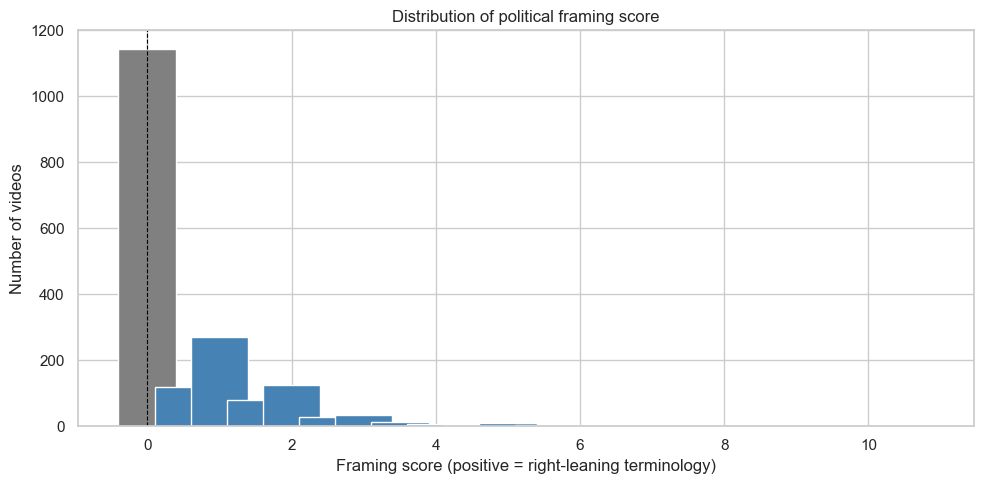

In [16]:
# Framing score distribution
fig, ax = plt.subplots(figsize=(10, 5))
score_counts = df["framing_score"].value_counts().sort_index()
colours = ["coral" if s < 0 else "steelblue" if s > 0 else "grey" for s in score_counts.index]
ax.bar(score_counts.index, score_counts.values, color=colours)
ax.set_xlabel("Framing score (positive = right-leaning terminology)")
ax.set_ylabel("Number of videos")
ax.set_title("Distribution of political framing score")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

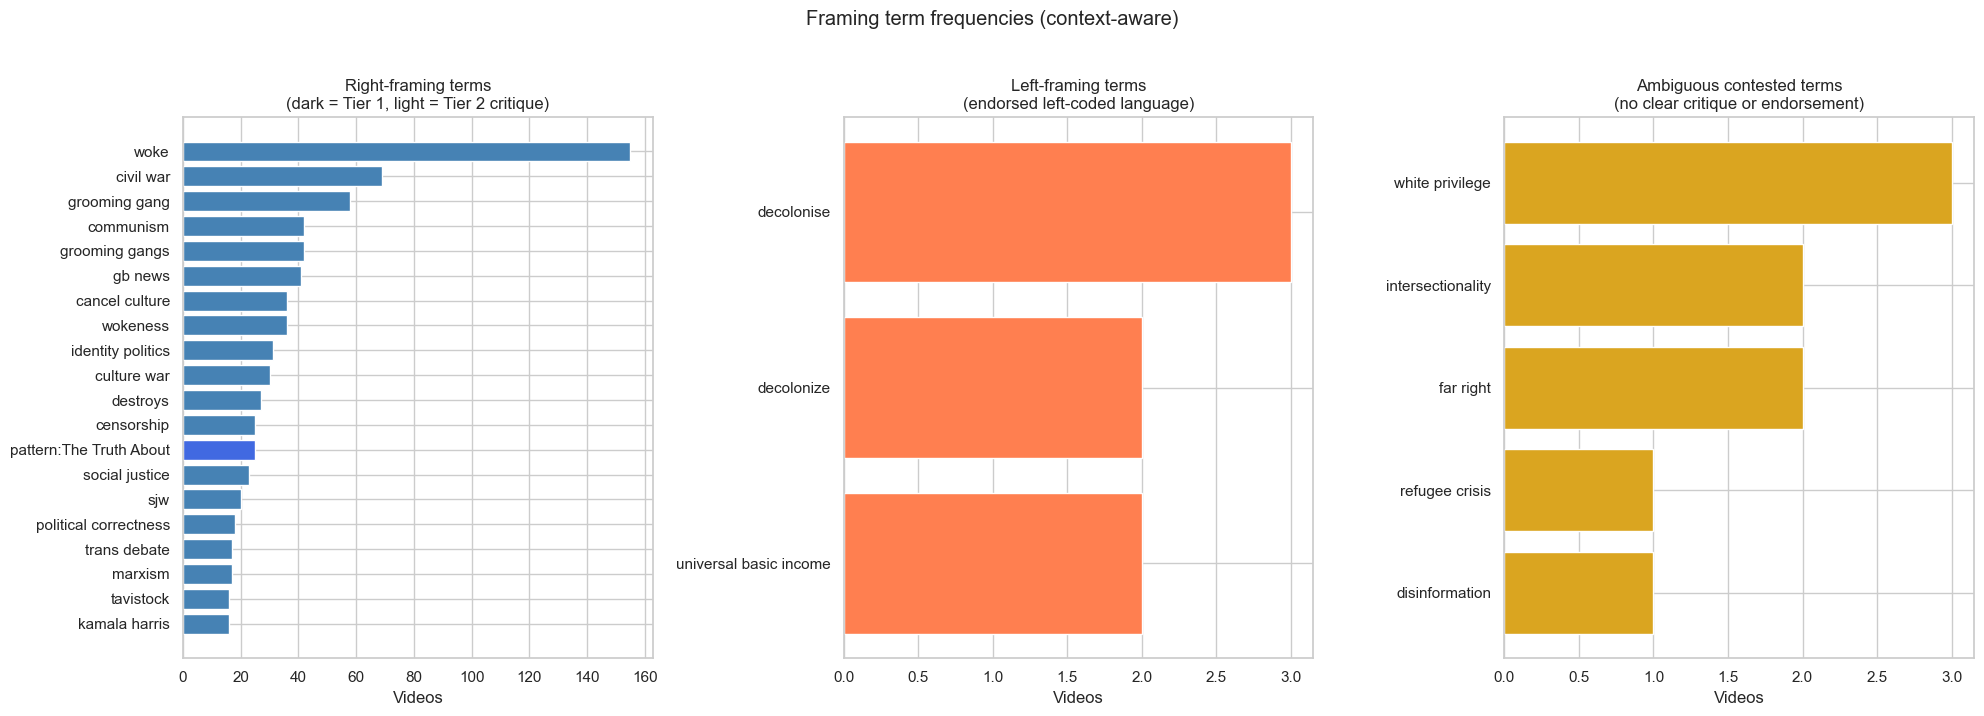

In [17]:
# Most common framing terms by tier and direction
right_term_counts = Counter(t for terms in df["framing_right_terms"] for t in terms)
left_term_counts = Counter(t for terms in df["framing_left_terms"] for t in terms)
ambig_term_counts = Counter(t for terms in df["framing_ambiguous_terms"] for t in terms)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Right framing
if right_term_counts:
    rt_top = right_term_counts.most_common(20)
    words_r, counts_r = zip(*rt_top)
    # Colour tier 1 vs tier 2 differently
    colours_r = ["steelblue" if w in TIER1_RIGHT else "royalblue" for w in words_r]
    axes[0].barh(range(len(words_r)), counts_r, color=colours_r)
    axes[0].set_yticks(range(len(words_r)))
    axes[0].set_yticklabels(words_r)
    axes[0].invert_yaxis()
axes[0].set_title("Right-framing terms\n(dark = Tier 1, light = Tier 2 critique)")
axes[0].set_xlabel("Videos")

# Left framing
if left_term_counts:
    lt_top = left_term_counts.most_common(20)
    words_l, counts_l = zip(*lt_top)
    axes[1].barh(range(len(words_l)), counts_l, color="coral")
    axes[1].set_yticks(range(len(words_l)))
    axes[1].set_yticklabels(words_l)
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No left-framing terms found", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12)
axes[1].set_title("Left-framing terms\n(endorsed left-coded language)")
axes[1].set_xlabel("Videos")

# Ambiguous
if ambig_term_counts:
    am_top = ambig_term_counts.most_common(20)
    words_a, counts_a = zip(*am_top)
    axes[2].barh(range(len(words_a)), counts_a, color="goldenrod")
    axes[2].set_yticks(range(len(words_a)))
    axes[2].set_yticklabels(words_a)
    axes[2].invert_yaxis()
else:
    axes[2].text(0.5, 0.5, "No ambiguous terms", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12)
axes[2].set_title("Ambiguous contested terms\n(no clear critique or endorsement)")
axes[2].set_xlabel("Videos")

plt.suptitle("Framing term frequencies (context-aware)", y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Show all Tier 2 matches with their context and classification
tier2_rows = []
for _, row in df.iterrows():
    for entry in row["framing_evidence"]:
        if entry.startswith("[T2"):
            title = row["title"]
            # Find the contested term in the evidence string
            tier2_rows.append({
                "title": title[:80],
                "evidence": entry,
            })

if tier2_rows:
    tier2_audit = pd.DataFrame(tier2_rows)
    print(f"Total Tier 2 contested term matches: {len(tier2_audit)}")
    print()

    # Group by classification
    for label, prefix in [("RIGHT (+1, critique)", "[T2 +1]"),
                          ("LEFT (-1, endorsement)", "[T2 -1]"),
                          ("AMBIGUOUS (0)", "[T2  0]")]:
        subset = tier2_audit[tier2_audit["evidence"].str.startswith(prefix)]
        print(f"\n{'='*80}")
        print(f"{label}: {len(subset)} matches")
        print(f"{'='*80}")
        for _, r in subset.iterrows():
            print(f"  {r['evidence']}")
            print(f"    → {r['title']}")
            print()
else:
    print("No Tier 2 matches found.")

Total Tier 2 contested term matches: 24


RIGHT (+1, critique): 0 matches

LEFT (-1, endorsement): 0 matches

AMBIGUOUS (0): 9 matches
  [T2  0] intersectionality (title, ambiguous)
    → Sargon of Akkad on Liberalism, Intersectionality & Immigration

  [T2  0] white privilege (title, ambiguous)
    → Remi Adekoya on Black Identity Politics, Racism, White Privilege & Populism

  [T2  0] white privilege (title, ambiguous)
    → Zuby on Positive Rap, Identifying as a Woman and White Privilege

  [T2  0] intersectionality (title, ambiguous)
    → Douglas Murray on Roger Scruton, Intersectionality and the Trans Debate

  [T2  0] refugee crisis (desc, ambiguous)
    → Can We Stop Terrorism and What Do Islamists Want?

  [T2  0] far right (title, ambiguous)
    → Nigel Farage: "I Did More to Stop the Far Right Than Anyone"

  [T2  0] white privilege (title, ambiguous)
    → Pure Truth! Theo Von on White Privilege

  [T2  0] far right (title, ambiguous)
    → We're All Far Right Now - Dominic

### Contextual evidence audit

Show the classification reasoning for every Tier 2 contested term match, so we can verify the context-detection is working correctly.

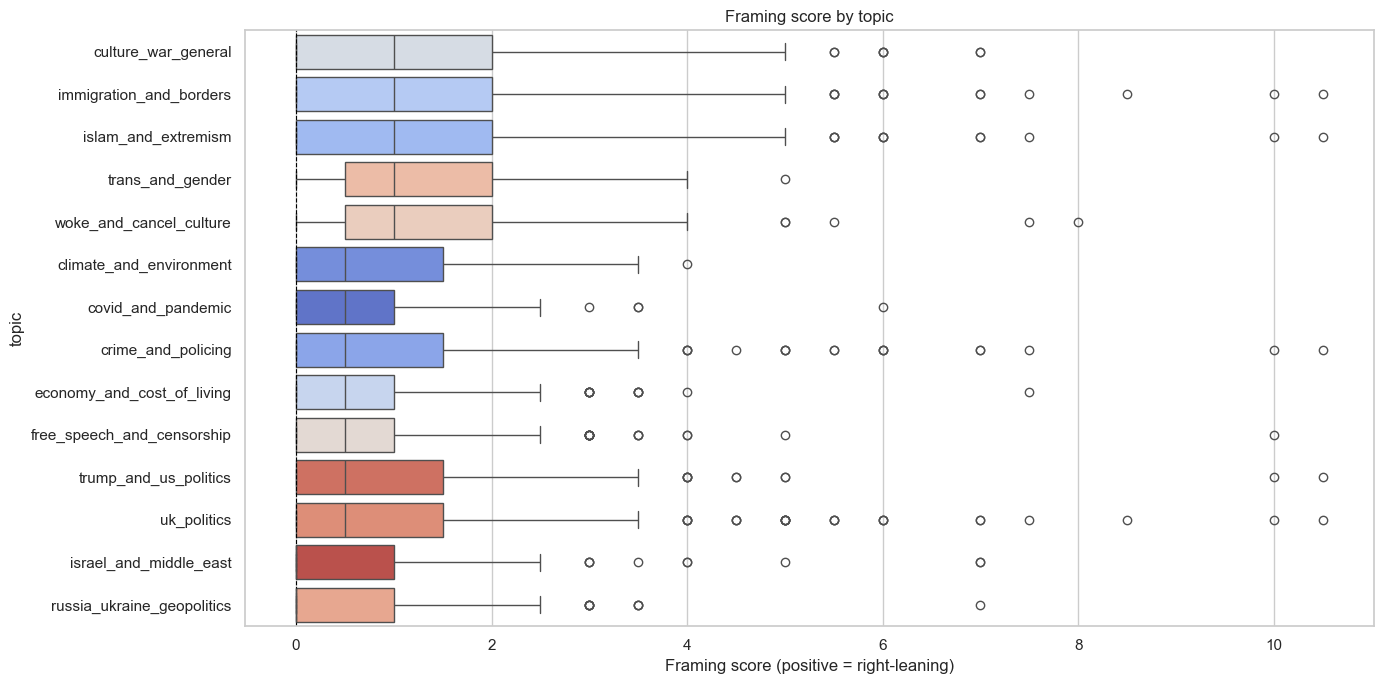

In [19]:
# Framing score by topic (box plot)
rows = []
for _, row in df.iterrows():
    for t in row["topics"]:
        rows.append({"topic": t, "framing_score": row["framing_score"]})

if rows:
    topic_framing = pd.DataFrame(rows)
    # Order by median framing score
    order = (
        topic_framing.groupby("topic")["framing_score"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.boxplot(
        data=topic_framing,
        y="topic",
        x="framing_score",
        hue="topic",
        order=order,
        ax=ax,
        palette="coolwarm_r",
        dodge=False,
        legend=False,
    )
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Framing score by topic")
    ax.set_xlabel("Framing score (positive = right-leaning)")
    plt.tight_layout()
    plt.show()

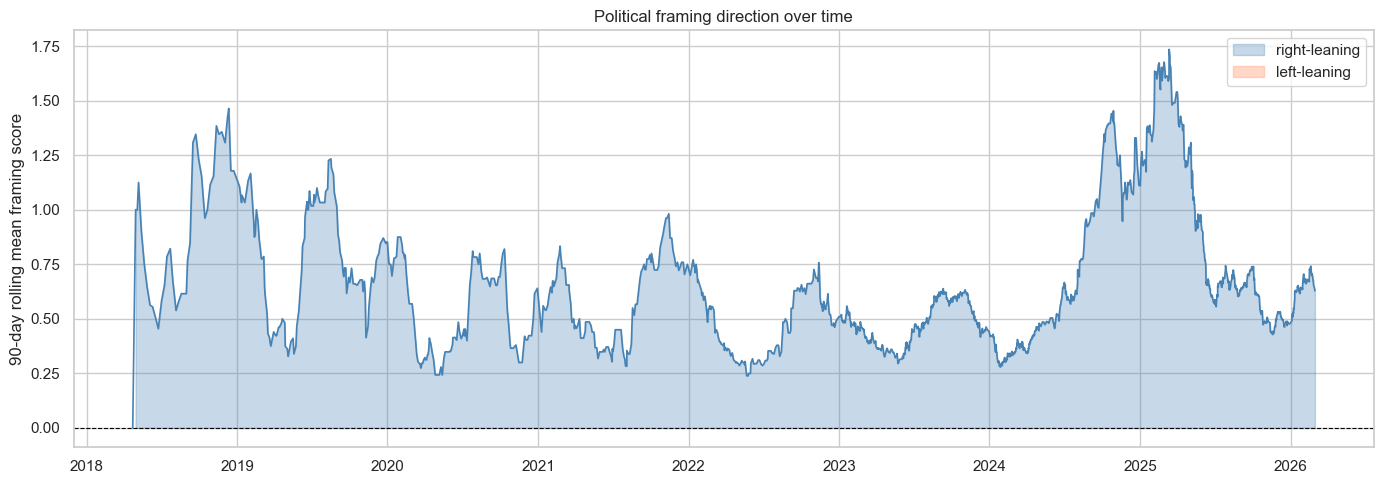

In [20]:
# Framing score trend over time (rolling 90-day mean)
ts = df.set_index("published_date")["framing_score"].sort_index()
rolling_framing = ts.rolling("90D").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_framing.index, rolling_framing.values, color="steelblue", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(rolling_framing.index, rolling_framing.values, 0,
                where=rolling_framing.values > 0, alpha=0.3, color="steelblue", label="right-leaning")
ax.fill_between(rolling_framing.index, rolling_framing.values, 0,
                where=rolling_framing.values < 0, alpha=0.3, color="coral", label="left-leaning")
ax.set_ylabel("90-day rolling mean framing score")
ax.set_title("Political framing direction over time")
ax.legend()
plt.tight_layout()
plt.show()

---

## 3 — VADER sentiment analysis

VADER is a lexicon-based sentiment analyser calibrated for social media text. It returns a compound score from −1 (most negative) to +1 (most positive).

- **Title** (always present, editorially curated) — weight **0.7**  
- **Cleaned description** (often empty for shorts) — weight **0.3** (or 0.0 when empty)

In [21]:
sia = SentimentIntensityAnalyzer()

df["vader_title"] = df["title"].fillna("").apply(
    lambda t: sia.polarity_scores(t)["compound"]
)
df["vader_desc"] = df["desc_clean"].apply(
    lambda t: sia.polarity_scores(t)["compound"] if len(t) > 20 else 0.0
)


def weighted_vader(row):
    if row["desc_clean_len"] > 20:
        return 0.7 * row["vader_title"] + 0.3 * row["vader_desc"]
    return row["vader_title"]


df["vader_composite"] = df.apply(weighted_vader, axis=1)

print("VADER summary (composite):")
print(df["vader_composite"].describe().round(3))

VADER summary (composite):
count    1849.000
mean       -0.051
std         0.356
min        -0.940
25%        -0.303
50%         0.000
75%         0.180
max         0.856
Name: vader_composite, dtype: float64


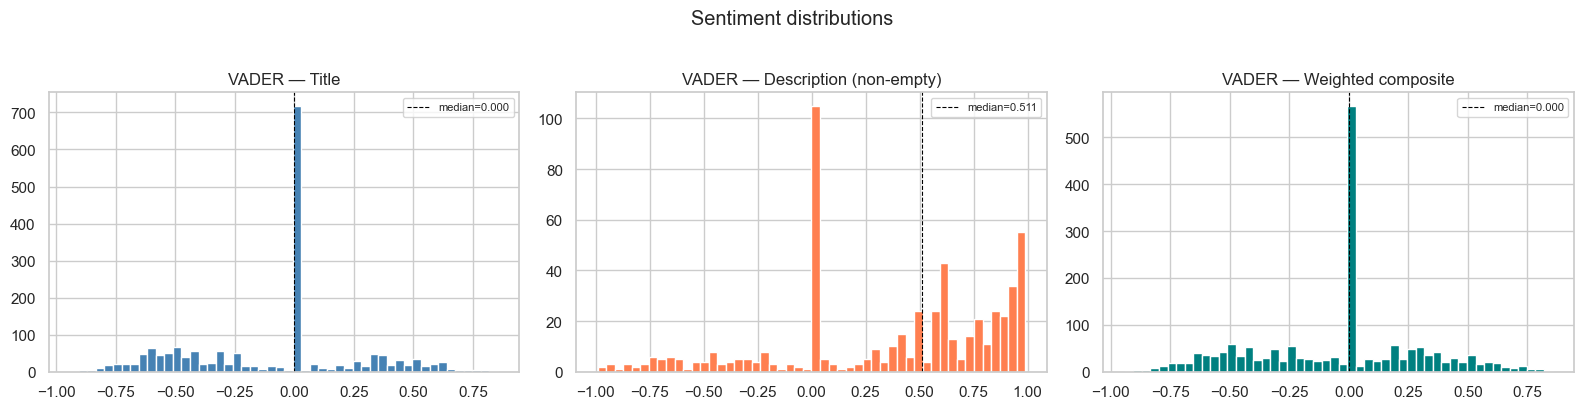

In [22]:
# VADER distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label, colour in [
    (axes[0], "vader_title", "Title", "steelblue"),
    (axes[1], "vader_desc", "Description (non-empty)", "coral"),
    (axes[2], "vader_composite", "Weighted composite", "teal"),
]:
    vals = df[col]
    if col == "vader_desc":
        vals = vals[df["desc_clean_len"] > 20]
    ax.hist(vals, bins=50, color=colour, edgecolor="white")
    ax.axvline(vals.median(), color="black", linestyle="--", linewidth=0.8,
               label=f"median={vals.median():.3f}")
    ax.set_title(f"VADER — {label}")
    ax.legend(fontsize=8)

plt.suptitle("Sentiment distributions", y=1.02)
plt.tight_layout()
plt.show()

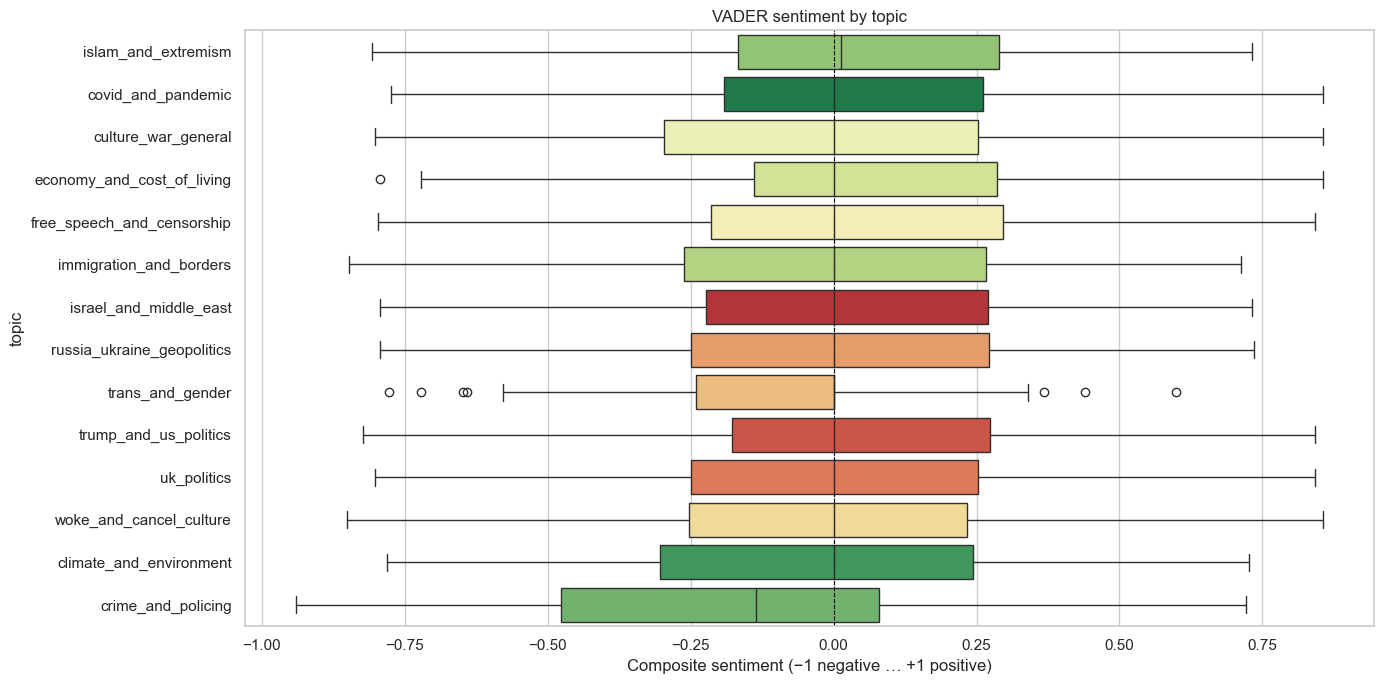

In [23]:
# VADER by topic
rows_v = []
for _, row in df.iterrows():
    for t in row["topics"]:
        rows_v.append({"topic": t, "vader_composite": row["vader_composite"]})

if rows_v:
    topic_vader = pd.DataFrame(rows_v)
    order_v = (
        topic_vader.groupby("topic")["vader_composite"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.boxplot(
        data=topic_vader,
        y="topic",
        x="vader_composite",
        hue="topic",
        order=order_v,
        ax=ax,
        palette="RdYlGn",
        dodge=False,
        legend=False,
    )
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("VADER sentiment by topic")
    ax.set_xlabel("Composite sentiment (−1 negative … +1 positive)")
    plt.tight_layout()
    plt.show()

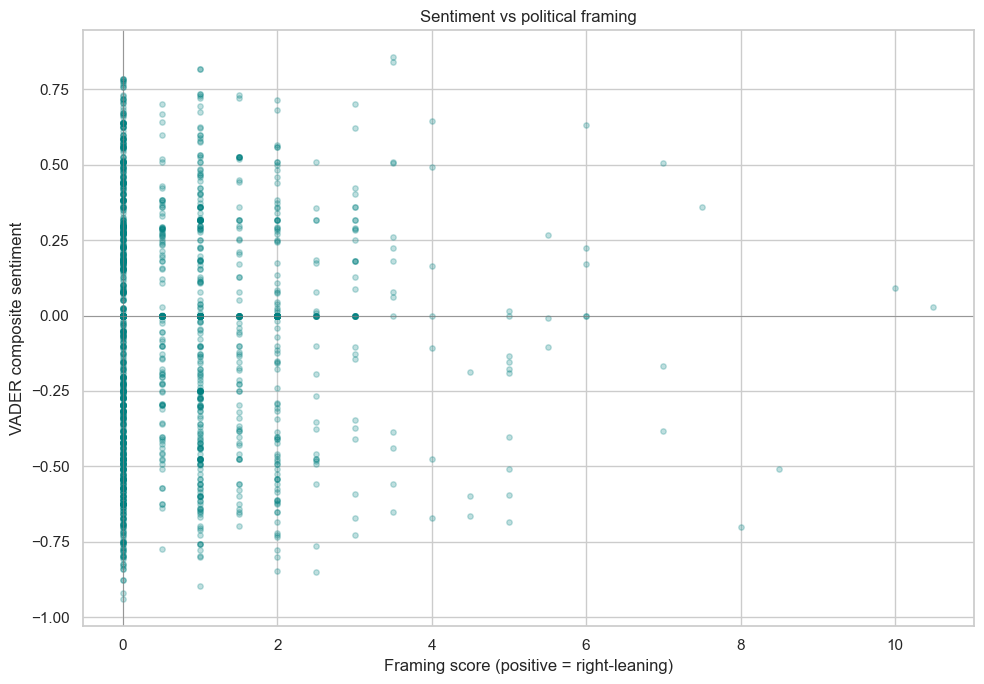

In [24]:
# VADER vs framing score scatter
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df["framing_score"], df["vader_composite"], alpha=0.25, s=15, color="teal")
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Framing score (positive = right-leaning)")
ax.set_ylabel("VADER composite sentiment")
ax.set_title("Sentiment vs political framing")
plt.tight_layout()
plt.show()

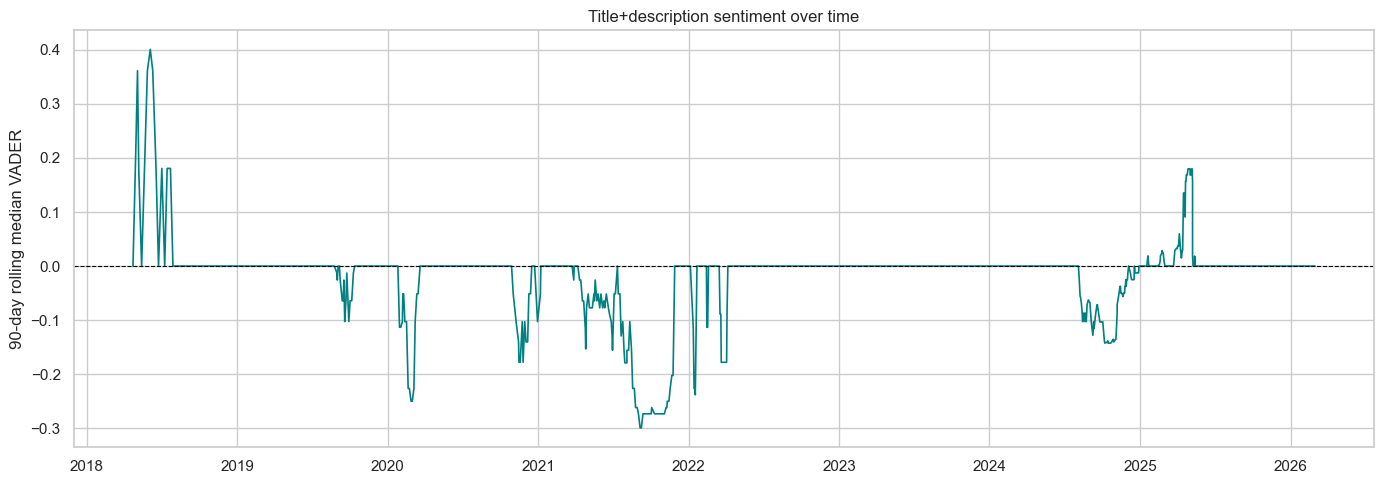

In [25]:
# Sentiment over time (rolling 90-day median)
ts_v = df.set_index("published_date")["vader_composite"].sort_index()
rolling_vader = ts_v.rolling("90D").median()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_vader.index, rolling_vader.values, color="teal", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("90-day rolling median VADER")
ax.set_title("Title+description sentiment over time")
plt.tight_layout()
plt.show()

---

## 4 — Contextual word analysis (PMI)

Pointwise Mutual Information measures how much more likely two words are to co-occur within a sliding window than by chance. This reveals what words cluster near politically charged anchor terms in video titles.

In [26]:
ANCHOR_WORDS = [
    "woke", "trans", "immigration", "israel", "trump",
    "covid", "left", "right", "culture", "women",
    "cancel", "war", "muslim", "climate", "free",
]

WINDOW = 5
MIN_COOC = 3

# Build co-occurrence counts from title tokens
cooc = defaultdict(Counter)
token_freq = Counter()

for tokens in df["title_tokens"]:
    token_freq.update(tokens)
    for i, tok_a in enumerate(tokens):
        start = max(0, i - WINDOW)
        end = min(len(tokens), i + WINDOW + 1)
        for j in range(start, end):
            if i != j:
                cooc[tok_a][tokens[j]] += 1

total_pairs = sum(sum(c.values()) for c in cooc.values())
total_tokens = sum(token_freq.values())

print(f"Unique tokens in titles: {len(token_freq):,}")
print(f"Total co-occurrence pairs: {total_pairs:,}")

Unique tokens in titles: 3,126
Total co-occurrence pairs: 42,532


In [27]:
def pmi(word_a, word_b):
    """Pointwise mutual information."""
    p_ab = cooc[word_a][word_b] / total_pairs
    p_a = token_freq[word_a] / total_tokens
    p_b = token_freq[word_b] / total_tokens
    if p_ab == 0 or p_a == 0 or p_b == 0:
        return 0.0
    return np.log2(p_ab / (p_a * p_b))


# Compute PMI for each anchor
anchor_pmi = {}
for anchor in ANCHOR_WORDS:
    if anchor not in cooc:
        continue
    associates = [
        (word, pmi(anchor, word), cooc[anchor][word])
        for word in cooc[anchor]
        if cooc[anchor][word] >= MIN_COOC and word not in ALL_STOPS
    ]
    associates.sort(key=lambda x: x[1], reverse=True)
    anchor_pmi[anchor] = associates[:15]

print(f"Anchors with results: {len(anchor_pmi)}")

Anchors with results: 15


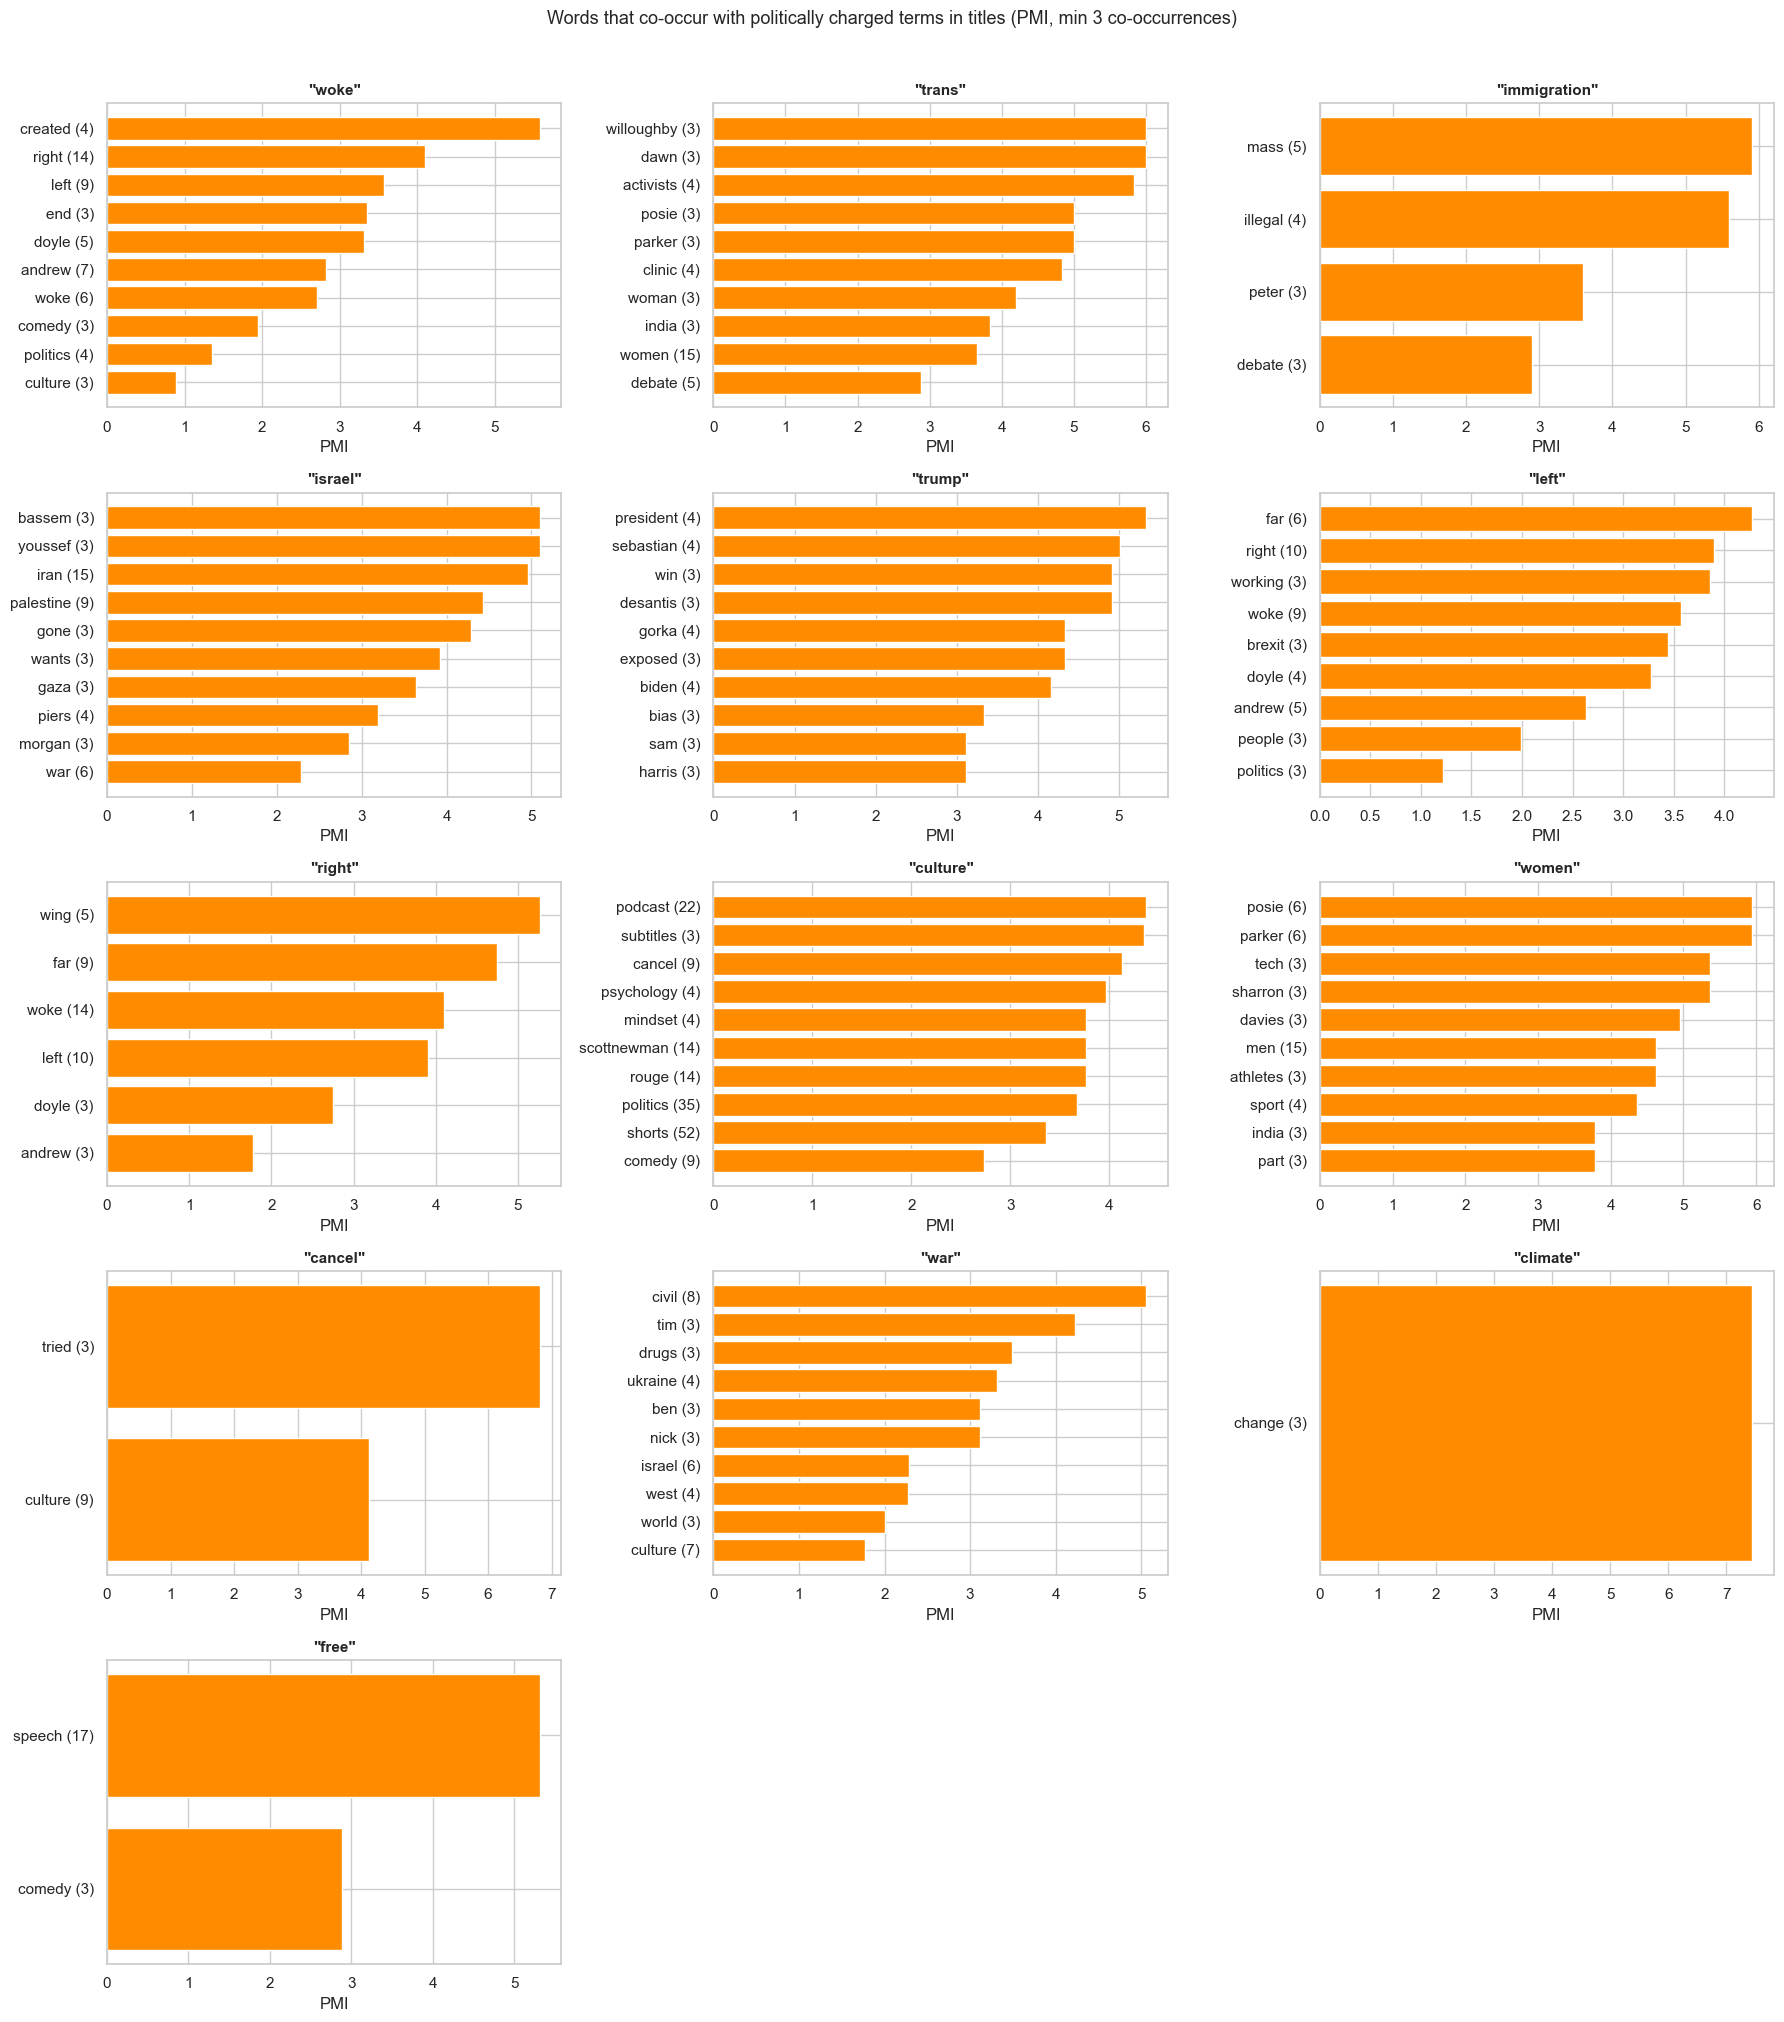

In [28]:
# PMI bar charts (small multiples)
active_anchors = [a for a in ANCHOR_WORDS if a in anchor_pmi and anchor_pmi[a]]
n_anchors = len(active_anchors)
ncols_p = 3
nrows_p = int(np.ceil(n_anchors / ncols_p))

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(18, nrows_p * 4))

for idx, anchor in enumerate(active_anchors):
    ax = axes.flat[idx]
    data = anchor_pmi[anchor][:10]
    if not data:
        continue
    words_p, pmi_vals, counts_p = zip(*data)
    ax.barh(range(len(words_p)), pmi_vals, color="darkorange")
    ax.set_yticks(range(len(words_p)))
    ax.set_yticklabels([f"{w} ({c})" for w, c in zip(words_p, counts_p)])
    ax.invert_yaxis()
    ax.set_title(f'"{anchor}"', fontsize=11, fontweight="bold")
    ax.set_xlabel("PMI")

for idx in range(n_anchors, len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.suptitle("Words that co-occur with politically charged terms in titles (PMI, min 3 co-occurrences)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---

## 5 — Combined profile & CSV export

In [29]:
# ── Original framing labels (preserved for comparison) ───────────────
def framing_label(row):
    """
    Unknown   = no framing terms matched at all (no signal).
    Contested = politically loaded Tier 2 terms present, but direction unclear (ambiguous context).
    Neutral   = right and left framing terms both found and cancel out (balanced framing).
    """
    score = row["framing_score"]
    right_count = row["framing_right_count"]
    left_count = row["framing_left_count"]
    ambiguous_count = row["framing_ambiguous_count"]

    if score > 0:
        return "right-leaning"
    if score < 0:
        return "left-leaning"
    # score == 0: discriminate unknown / contested / neutral
    if right_count > 0 and left_count > 0:
        return "neutral"
    if ambiguous_count > 0:
        return "contested"
    return "unknown"


df["framing_label"] = df.apply(framing_label, axis=1)

# ── Combined score: lexicon + guest + tags ───────────────────────────
df["combined_score"] = df["framing_score"] + df["guest_signal"]

# Track which signal sources contributed
def get_signal_sources(row):
    sources = []
    # Lexicon signal (from title/desc, excluding tags)
    lexicon_score = row["framing_score"] - row["tags_framing_score"]
    if lexicon_score != 0 or row["framing_ambiguous_count"] > 0:
        sources.append("lexicon")
    if row["tags_framing_score"] != 0:
        sources.append("tags")
    if row["guest_signal"] != 0:
        sources.append("guest")
    return "|".join(sources) if sources else ""


df["signal_sources"] = df.apply(get_signal_sources, axis=1)


def combined_label(row):
    """Final classification using all signal sources.

    Thresholds:
      combined_score >= 0.5  -> right-leaning  (a single tag hit at 0.5 weight counts)
      combined_score <= -0.5 -> left-leaning
      signals from both directions -> contested
      signals present but weak (0 < |score| < 0.5) -> neutral
      no signals at all -> unknown
    """
    score = row["combined_score"]
    sources = row["signal_sources"]

    if not sources:
        return "unknown"

    if score >= 0.5:
        return "right-leaning"
    if score <= -0.5:
        return "left-leaning"

    # Check for opposing signals
    has_right = row["framing_right_count"] > 0 or row["guest_signal"] > 0
    has_left = row["framing_left_count"] > 0 or row["guest_signal"] < 0
    if has_right and has_left:
        return "contested"

    # Has signal but weak (e.g. single ambiguous Tier 2 term, or contested guest)
    if row["framing_ambiguous_count"] > 0:
        return "contested"

    return "neutral"


df["combined_label"] = df.apply(combined_label, axis=1)


def confidence_level(row):
    """Confidence in the classification based on signal agreement and strength."""
    sources = row["signal_sources"]
    if not sources:
        return "none"

    n_sources = len(sources.split("|"))
    score_magnitude = abs(row["combined_score"])

    if n_sources >= 2 and score_magnitude >= 1.0:
        return "high"
    if n_sources >= 2 or score_magnitude >= 1.0:
        return "medium"
    return "low"


df["confidence"] = df.apply(confidence_level, axis=1)

# ── Summary ──────────────────────────────────────────────────────────
print("=== Original framing_label (lexicon + tags, no guest) ===")
old_counts = df["framing_label"].value_counts()
for label, count in old_counts.items():
    print(f"  {label:20s} {count:>5,}  ({count/len(df):.1%})")

print(f"\n=== Combined label (lexicon + tags + guest) ===")
new_counts = df["combined_label"].value_counts()
for label, count in new_counts.items():
    print(f"  {label:20s} {count:>5,}  ({count/len(df):.1%})")

old_unknown = old_counts.get("unknown", 0)
new_unknown = new_counts.get("unknown", 0)
print(f"\nUnknown reduction: {old_unknown:,} -> {new_unknown:,} ({old_unknown - new_unknown:,} reclassified)")

print(f"\n=== Confidence distribution ===")
print(df["confidence"].value_counts().to_string())

=== Original framing_label (lexicon + tags, no guest) ===
  unknown              1,136  (61.4%)
  right-leaning          706  (38.2%)
  contested                4  (0.2%)
  neutral                  3  (0.2%)

=== Combined label (lexicon + tags + guest) ===
  right-leaning          937  (50.7%)
  unknown                903  (48.8%)
  left-leaning             6  (0.3%)
  contested                3  (0.2%)

Unknown reduction: 1,136 -> 903 (233 reclassified)

=== Confidence distribution ===
confidence
none      903
medium    535
high      308
low       103


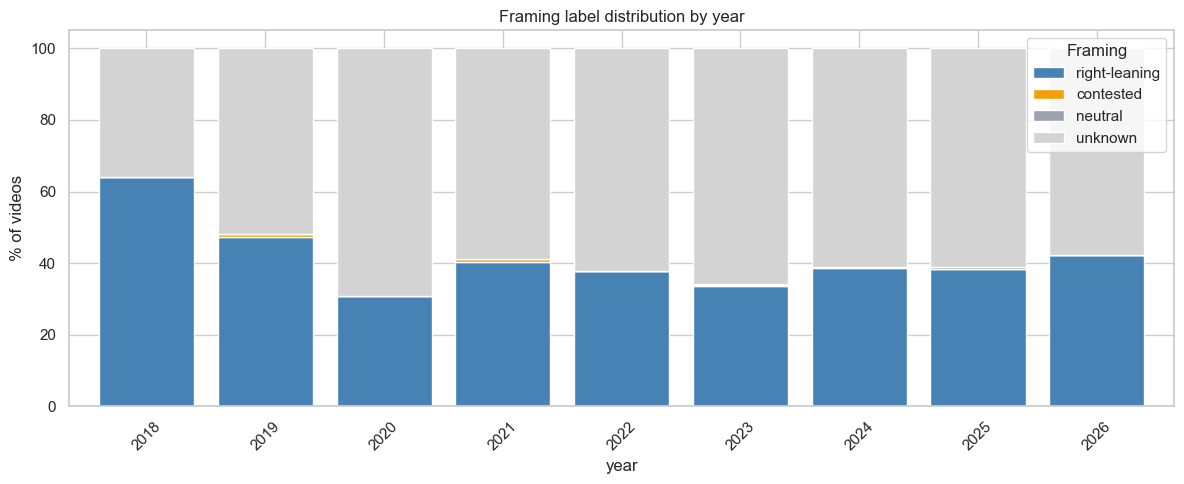

In [30]:
# Framing label by year (stacked bar)
ct = pd.crosstab(df["year"], df["framing_label"], normalize="index") * 100
colour_map = {
    "right-leaning": "steelblue",
    "left-leaning": "coral",
    "contested": "#F59E0B",
    "neutral": "#9CA3AF",
    "unknown": "lightgrey",
}
plot_order = [c for c in ["right-leaning", "contested", "neutral", "unknown", "left-leaning"] if c in ct.columns]

fig, ax = plt.subplots(figsize=(12, 5))
ct[plot_order].plot(kind="bar", stacked=True, ax=ax,
                    color=[colour_map[c] for c in plot_order], width=0.8)
ax.set_ylabel("% of videos")
ax.set_title("Framing label distribution by year")
ax.legend(title="Framing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


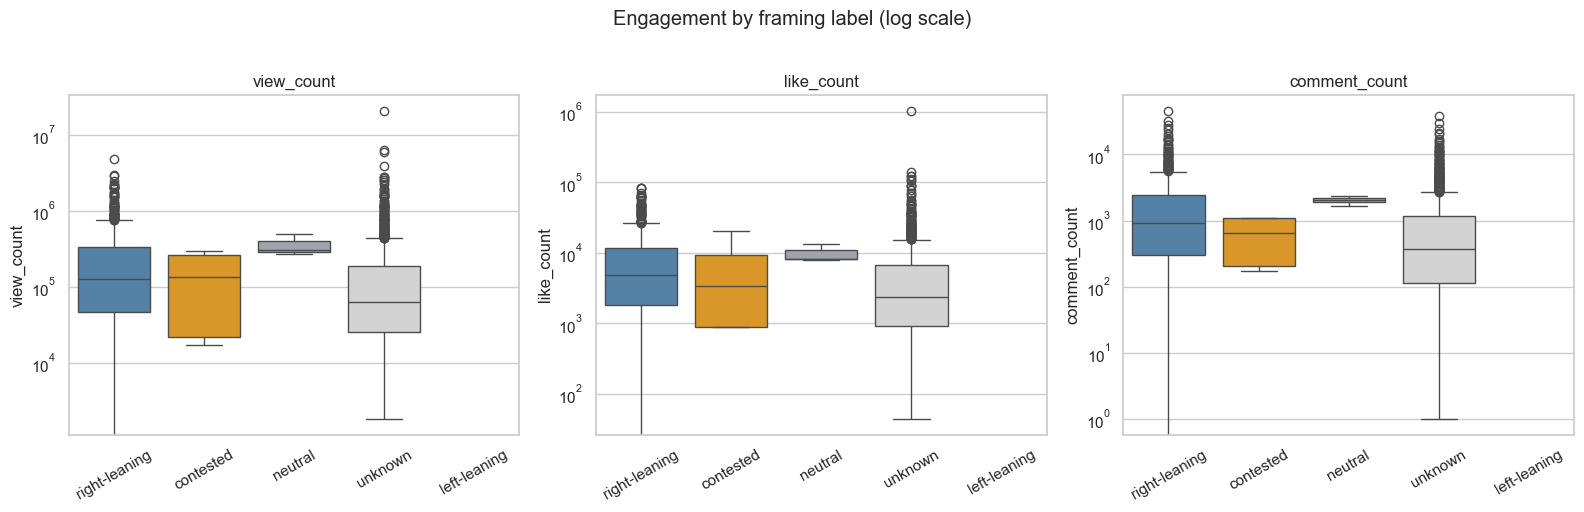

In [31]:
# Engagement vs framing
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["view_count", "like_count", "comment_count"]):
    sns.boxplot(
        data=df,
        x="framing_label",
        y=col,
        hue="framing_label",
        ax=ax,
        order=["right-leaning", "contested", "neutral", "unknown", "left-leaning"],
        palette=colour_map,
        dodge=False,
        legend=False,
    )
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Engagement by framing label (log scale)", y=1.02)
plt.tight_layout()
plt.show()


In [32]:
# Summary table per topic
summary_rows = []
for topic in sorted(TOPIC_KEYWORDS.keys()):
    mask = df["topics"].apply(lambda t: topic in t)
    sub = df[mask]
    if len(sub) == 0:
        continue
    summary_rows.append({
        "topic": topic,
        "n_videos": len(sub),
        "pct_of_total": round(len(sub) / len(df) * 100, 1),
        "mean_framing_score": round(sub["framing_score"].mean(), 2),
        "median_vader": round(sub["vader_composite"].median(), 3),
        "mean_views": int(sub["view_count"].mean()),
    })

summary = pd.DataFrame(summary_rows).sort_values("n_videos", ascending=False)
summary

,topic,n_videos,pct_of_total,mean_framing_score,median_vader,mean_views
12,uk_politics,467,25.3,0.98,0.000,291906
3,culture_war_general,330,17.8,1.13,0.000,235680
5,free_speech_and_censorship,301,16.3,0.73,0.000,284293
11,trump_and_us_politics,289,15.6,0.92,0.000,309050
13,woke_and_cancel_culture,265,14.3,1.45,0.000,342358
9,russia_ukraine_geopolitics,168,9.1,0.65,0.000,473239
8,israel_and_middle_east,160,8.7,0.76,0.000,432152
2,crime_and_policing,157,8.5,1.24,-0.135,257652
6,immigration_and_borders,142,7.7,1.68,0.000,278903
4,economy_and_cost_of_living,125,6.8,0.84,0.000,281686


In [33]:
# Top 10 most left-framed videos
print("Top 10 most left-framed videos:\n")
df.nsmallest(10, "framing_score")[
    ["published_date", "title", "framing_score", "framing_left_terms", "view_count"]
]

Top 10 most left-framed videos:



,published_date,title,framing_score,framing_left_terms,view_count
0,2018-04-23,"Gideon Rachman on Trump, Russia, China, Israel...",0.0,[],9316
4,2018-05-14,"Dr Pippa Malmgren on Populism, Russia and AI",0.0,[],4813
5,2018-05-21,David Pilling on the Growth Delusion and Good ...,0.0,[],2659
6,2018-05-28,"Peter Tatchell on Human Rights, Free Speech an...",0.0,[],4290
7,2018-06-04,"Rory Sutherland on the Logic Trap, Humour & Fr...",0.0,[],23105
9,2018-06-18,"Dr Linda Yueh on Inequality, China and the End...",0.0,[],3539
10,2018-06-24,"Jeremy Shapiro on Trump, Trident, Israel & Iran",0.0,[],2183
15,2018-07-29,"Iain Dale on Conservatism, Immigration, Tax & ...",0.0,[],14106
16,2018-08-06,"Scott Capurro on Comedy, Offence and Politics ...",0.0,[],6817
19,2018-08-31,TRIGGERnometry Read Mean Tweets,0.0,[],10687


In [34]:
# --- Export classified CSV + persistent unknown review files ---

# Prepare export columns
export_df = df.copy()

# Convert list columns to pipe-separated strings for CSV compatibility
export_df["topics"] = export_df["topics"].apply(lambda x: "|".join(x) if isinstance(x, list) else "")
export_df["framing_right_terms"] = export_df["framing_right_terms"].apply(lambda x: "|".join(x) if isinstance(x, list) else "")
export_df["framing_left_terms"] = export_df["framing_left_terms"].apply(lambda x: "|".join(x) if isinstance(x, list) else "")
export_df["framing_terms_matched"] = (
    export_df["framing_right_terms"].str.cat(export_df["framing_left_terms"], sep="|").str.strip("|")
)
export_df["tags_framing_terms"] = export_df["tags_framing_terms"].apply(lambda x: "|".join(x) if isinstance(x, list) else "")
export_df["guest_talking_points_matched"] = export_df["guest_talking_points_matched"].apply(
    lambda x: "|".join(x) if isinstance(x, list) else ""
)

# Select columns for export
export_cols = [
    # Original columns
    "published_date", "type", "title", "description", "url",
    "view_count", "like_count", "comment_count", "category_id", "tags", "topic_categories",
    # Topic classification
    "topics",
    # Lexicon framing (original)
    "framing_score", "framing_label", "framing_terms_matched",
    # Tags signal
    "tags_framing_score", "tags_framing_terms",
    # Guest signal
    "guest_name_detected", "guest_signal", "guest_style", "guest_talking_points_matched",
    # Combined classification
    "combined_score", "combined_label", "signal_sources", "confidence",
    # Sentiment
    "vader_title", "vader_desc", "vader_composite",
]

PROJECT_ROOT = Path(DATA_PATH).resolve().parents[2]
EXPORT_DIR = PROJECT_ROOT / "data/TRIGGERnometry-video-taxonomy"
OUT_PATH = EXPORT_DIR / "trigggerpod-classified.csv"
UNKNOWN_REVIEW_CSV = EXPORT_DIR / "unknowns-review.csv"
UNKNOWN_REVIEW_MD = EXPORT_DIR / "unknowns-review.md"

export_df[export_cols].to_csv(OUT_PATH, index=False)

# Persistent manual-review queue for unknowns
unknown_review = df[df["combined_label"] == "unknown"].copy()
unknown_review["is_right_guest_hint"] = unknown_review["guest_name_detected"].isin(RIGHT_GUEST_HINTS)
unknown_review["is_forced_guest_override"] = unknown_review["guest_talking_points_matched"].apply(
    lambda x: isinstance(x, list) and "guest_override" in x
)
unknown_review["topics"] = unknown_review["topics"].apply(lambda x: "|".join(x) if isinstance(x, list) else "")
unknown_review["guest_talking_points_matched"] = unknown_review["guest_talking_points_matched"].apply(
    lambda x: "|".join(x) if isinstance(x, list) else ""
)
unknown_review["manual_label"] = ""  # fill manually: right-leaning / left-leaning / neutral / contested
unknown_review["manual_notes"] = ""  # free-text notes after review

unknown_review = unknown_review.sort_values(
    ["is_right_guest_hint", "guest_signal", "published_date"],
    ascending=[False, False, False],
)

unknown_review_cols = [
    "published_date", "title", "url", "guest_name_detected", "guest_signal", "guest_style",
    "is_right_guest_hint", "is_forced_guest_override",
    "topics", "signal_sources", "framing_score", "combined_score",
    "guest_talking_points_matched", "manual_label", "manual_notes",
]
unknown_review[unknown_review_cols].to_csv(UNKNOWN_REVIEW_CSV, index=False)

# Lightweight markdown companion so unknowns are easy to comment on in-repo
md_rows = unknown_review.head(300).copy()
md_lines = [
    "# Unknown videos for manual review",
    "",
    "Auto-generated by `03-political-bias-by-topic.ipynb`.",
    "Prioritized by right-guest hints and stronger guest signal.",
    "Use `manual_label`/`manual_notes` in `unknowns-review.csv` for persistent annotations.",
    "",
    "| date | title | guest | guest_signal | right_hint | topics |",
    "|---|---|---|---:|---|---|",
]
for _, row in md_rows.iterrows():
    date = str(row["published_date"])[:10]
    title = str(row["title"]).replace("|", "\\|")
    guest = str(row["guest_name_detected"] or "").replace("|", "\\|")
    score = f"{float(row['guest_signal']):.2f}"
    right_hint = "yes" if bool(row["is_right_guest_hint"]) else ""
    topics = str(row["topics"]).replace("|", ", ")
    md_lines.append(f"| {date} | {title} | {guest} | {score} | {right_hint} | {topics} |")

UNKNOWN_REVIEW_MD.write_text("\n".join(md_lines), encoding="utf-8")

unknown_count = (export_df["combined_label"] == "unknown").sum()
right_count = (export_df["combined_label"] == "right-leaning").sum()
contested_count = (export_df["combined_label"] == "contested").sum()
left_count = (export_df["combined_label"] == "left-leaning").sum()
neutral_count = (export_df["combined_label"] == "neutral").sum()

print(f"Exported {len(export_df):,} rows to {OUT_PATH}")
print(f"  Columns: {len(export_cols)}")
print(f"\n  Combined label distribution:")
print(f'    right-leaning:  {right_count:>5,}  ({right_count/len(df):.1%})')
print(f'    left-leaning:   {left_count:>5,}  ({left_count/len(df):.1%})')
print(f'    contested:      {contested_count:>5,}  ({contested_count/len(df):.1%})')
print(f'    neutral:        {neutral_count:>5,}  ({neutral_count/len(df):.1%})')
print(f'    unknown:        {unknown_count:>5,}  ({unknown_count/len(df):.1%})')
print(f"\nWrote unknown review queue:")
print(f"  CSV: {UNKNOWN_REVIEW_CSV}")
print(f"  MD : {UNKNOWN_REVIEW_MD}")

Exported 1,849 rows to /Users/nathanormond/Dev/playground/statistics-notes/data/TRIGGERnometry-video-taxonomy/trigggerpod-classified.csv
  Columns: 28

  Combined label distribution:
    right-leaning:    937  (50.7%)
    left-leaning:       6  (0.3%)
    contested:          3  (0.2%)
    neutral:            0  (0.0%)
    unknown:          903  (48.8%)

Wrote unknown review queue:
  CSV: /Users/nathanormond/Dev/playground/statistics-notes/data/TRIGGERnometry-video-taxonomy/unknowns-review.csv
  MD : /Users/nathanormond/Dev/playground/statistics-notes/data/TRIGGERnometry-video-taxonomy/unknowns-review.md


### Audit: signal source breakdown

How many videos were reclassified from "unknown" by each signal source?
Spot-check key guests to verify the per-episode context approach is working correctly.

In [35]:
# ── Audit: what reclassified the unknowns? ───────────────────────────

# Compare old vs new
comparison = pd.crosstab(df["framing_label"], df["combined_label"], margins=True)
print("=== Old framing_label vs new combined_label (crosstab) ===")
print(comparison.to_string())

# Which signal sources moved videos out of unknown?
was_unknown = df["framing_label"] == "unknown"
now_classified = df["combined_label"] != "unknown"
reclassified = df[was_unknown & now_classified]

print(f"\n=== Videos reclassified from 'unknown' ({len(reclassified):,}) ===")
if len(reclassified) > 0:
    print("\nBy signal source:")
    print(reclassified["signal_sources"].value_counts().to_string())

    print("\nBy new label:")
    print(reclassified["combined_label"].value_counts().to_string())

# ── Spot-check key guests ────────────────────────────────────────────
spot_check_guests = [
    "Douglas Murray", "Sam Harris", "Jordan Peterson",
    "Andrew Doyle", "Ben Shapiro", "Laurence Fox",
]

print("\n=== Guest spot-checks ===")
for guest in spot_check_guests:
    mask = df["guest_name_detected"] == guest
    if mask.sum() == 0:
        continue
    sub = df[mask][["title", "guest_signal", "combined_label", "signal_sources", "confidence"]].copy()
    sub["title"] = sub["title"].str[:70]
    print(f"\n{guest} ({mask.sum()} episodes):")
    print(sub.to_string(index=False))

=== Old framing_label vs new combined_label (crosstab) ===
combined_label  contested  left-leaning  right-leaning  unknown   All
framing_label                                                        
contested               3             0              1        0     4
neutral                 0             0              3        0     3
right-leaning           0             0            706        0   706
unknown                 0             6            227      903  1136
All                     3             6            937      903  1849

=== Videos reclassified from 'unknown' (233) ===

By signal source:
signal_sources
guest    233

By new label:
combined_label
right-leaning    227
left-leaning       6

=== Guest spot-checks ===

Douglas Murray (14 episodes):
                                                                 title  guest_signal combined_label     signal_sources confidence
  Douglas Murray on Roger Scruton and the Fall of the Mainstream Media           1.0  right-le

### Methodological limitations

1. **Lexicon coverage** — The framing lexicon is manually curated and inevitably incomplete. New framing patterns emerge over time.
2. **Context detection is heuristic** — The critique/endorsement marker approach catches obvious signals (scare quotes, "myth", "debunks") but can miss subtler framing (irony, rhetorical questions, guest quotes used as editorial endorsement).
3. **Title-heavy analysis** — ~70% of videos have boilerplate-only descriptions, making titles the primary signal. This captures editorial framing but misses nuance in spoken content.
4. **VADER calibration** — VADER is designed for social media text and may misinterpret irony, questions, and quotation-style titles.
5. **Topic overlap** — Videos can belong to multiple topics, which inflates apparent prevalence.
6. **Framing ≠ content** — This measures word-choice framing, not the substantive argument or conclusion of each video.

### Next steps

- **Qualitative analysis** on `unknown` rows — thumbnail review, manual classification, to fill gaps the lexicon misses
- **Audit ambiguous Tier 2 matches** — manual review of contested terms where no critique/endorsement marker was detected
- Guest-name extraction and political affiliation mapping
- Cross-referencing framing scores with engagement to test audience–framing feedback loops

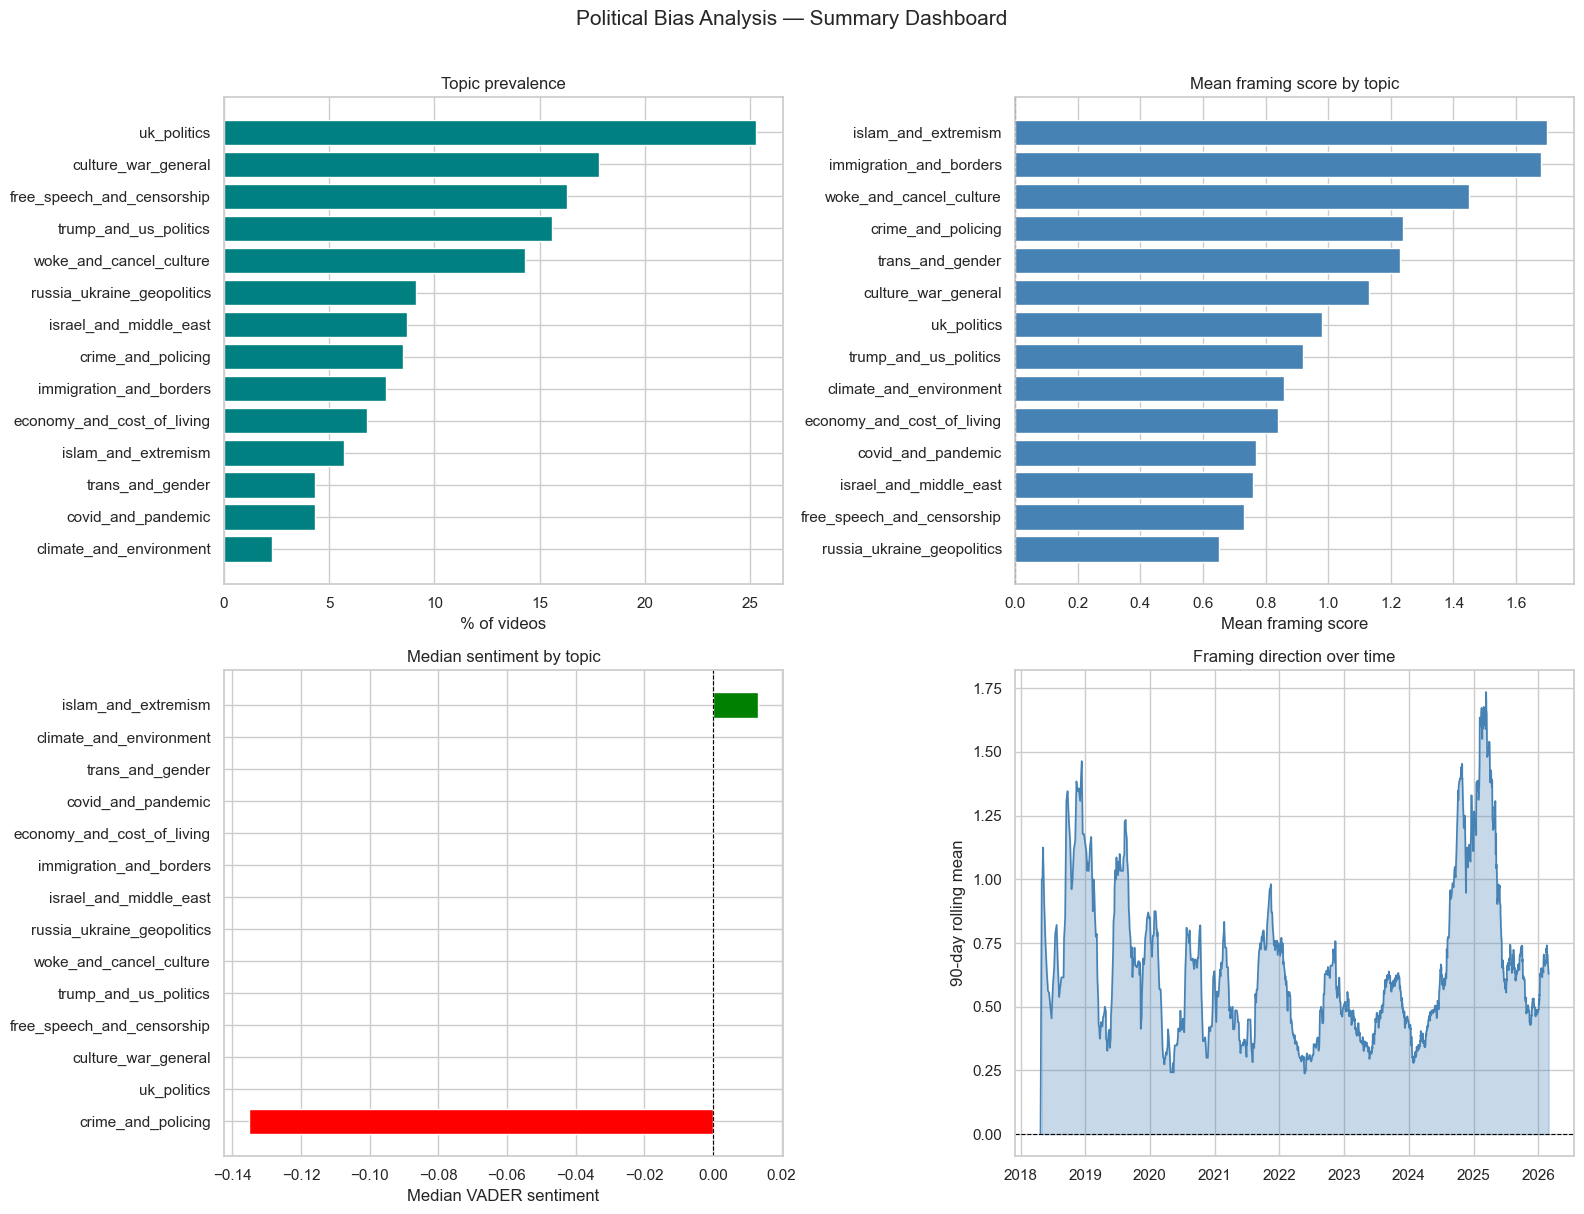

In [36]:
# Summary dashboard — 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1 — Topic prevalence
ax1 = axes[0, 0]
ax1.barh(topic_df["topic"], topic_df["pct"], color="teal")
ax1.invert_yaxis()
ax1.set_xlabel("% of videos")
ax1.set_title("Topic prevalence")

# 2 — Mean framing score by topic
ax2 = axes[0, 1]
s = summary.sort_values("mean_framing_score", ascending=True)
colours_s = ["steelblue" if v > 0 else "coral" if v < 0 else "grey" for v in s["mean_framing_score"]]
ax2.barh(s["topic"], s["mean_framing_score"], color=colours_s)
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Mean framing score")
ax2.set_title("Mean framing score by topic")

# 3 — Median VADER by topic
ax3 = axes[1, 0]
s2 = summary.sort_values("median_vader", ascending=True)
colours_v = ["green" if v > 0 else "red" if v < 0 else "grey" for v in s2["median_vader"]]
ax3.barh(s2["topic"], s2["median_vader"], color=colours_v)
ax3.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_xlabel("Median VADER sentiment")
ax3.set_title("Median sentiment by topic")

# 4 — Framing over time
ax4 = axes[1, 1]
ax4.plot(rolling_framing.index, rolling_framing.values, color="steelblue", linewidth=1.2)
ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax4.fill_between(rolling_framing.index, rolling_framing.values, 0,
                 where=rolling_framing.values > 0, alpha=0.3, color="steelblue")
ax4.fill_between(rolling_framing.index, rolling_framing.values, 0,
                 where=rolling_framing.values < 0, alpha=0.3, color="coral")
ax4.set_ylabel("90-day rolling mean")
ax4.set_title("Framing direction over time")

plt.suptitle("Political Bias Analysis — Summary Dashboard", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Methodological limitations

1. **Lexicon coverage** — The framing lexicon is manually curated and inevitably incomplete. New framing patterns emerge over time.
2. **Title-heavy analysis** — ~40% of videos have boilerplate-only descriptions, making titles the primary signal. This captures editorial framing but misses nuance in spoken content.
3. **VADER calibration** — VADER is designed for social media text and may misinterpret irony, questions, and quotation-style titles.
4. **Topic overlap** — Videos can belong to multiple topics, which inflates apparent prevalence.
5. **Framing ≠ content** — This measures word-choice framing, not the substantive argument or conclusion of each video.

### Next steps

- **Qualitative analysis** on `unknown` rows — thumbnail review, manual classification, to fill gaps the lexicon misses
- Guest-name extraction and political affiliation mapping
- Cross-referencing framing scores with engagement to test audience–framing feedback loops